# Autocorrelation espacial

In [1]:
from geoalchemy2 import Geometry, WKTElement
from sqlalchemy import *

db_url = 'postgresql://postgres:@localhost:5432/geodb'
engine = create_engine(db_url, echo=False)

In [2]:
dados = engine.execute("""
SELECT vc.num_votos, c.nome, ST_AsText(m.geom), m.nome
FROM voto_candidato as vc
INNER JOIN municipio as m
  ON m.id = vc.id_municipio
INNER JOIN candidato as c
  ON c.id = vc.id_candidato
""").fetchall()

/tmp/ipykernel_8642/99785675.py:1: RemovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  dados = engine.execute("""


In [3]:
import esda
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
import libpysal as lps
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
%matplotlib inline

In [4]:
df = pd.DataFrame(
    {
        "geometry": [i[2] for i in dados],
        "num_votos": [i[0] for i in dados],
        "candidado": [i[1] for i in dados],
        "municipio_id":[i[3] for i in dados]
    }
)

In [7]:
from matplotlib import colors
import mapclassify as mc

In [5]:
from shapely import wkt

df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
gdf = GeoDataFrame(df, crs="EPSG:4674")

In [62]:
def plot_all_municipio(candidado, p=[0.01, 0.05, 0.1]):
    gdf_k = gdf[gdf['candidado'] == candidado]
    
    df = gdf_k
    wq =  lps.weights.Queen.from_dataframe(df)
    wq.transform = 'r'
    
    y = df['num_votos']
    ylag = lps.weights.lag_spatial(wq, y)
    
    ylagq5 = mc.Quantiles(ylag, k=5)
    
    f, ax = plt.subplots(1, figsize=(9, 9))
    df.assign(cl=ylagq5.yb).plot(column='cl', categorical=True, \
            k=5, cmap='GnBu', linewidth=0.1, ax=ax, \
            edgecolor='white', legend=True)
    ax.set_axis_off()
    plt.title("Spatial Lag - Número de Votos (Quantiles)")
    plt.savefig(f"./images/numero-votos-{candidado}-spatial-lag.png", bbox_inches='tight')
    plt.show()

    wq.transform = 'r'
    lag_price = lps.weights.lag_spatial(wq, df['num_votos'])
    price = df['num_votos']
    b, a = np.polyfit(price, lag_price, 1)
    f, ax = plt.subplots(1, figsize=(9, 9))
    plt.plot(price, lag_price, '.', color='firebrick')
    plt.vlines(price.mean(), lag_price.min(), lag_price.max(), linestyle='--')
    plt.hlines(lag_price.mean(), price.min(), price.max(), linestyle='--')
    plt.plot(price, a + b*price, 'r')
    plt.title('Moran Scatterplot')
    plt.ylabel('Spatial Lag - Número de Votos')
    plt.xlabel('Número de Votos')
    plt.savefig(f"./images/numero-votos-{candidado}-moran-scatterplot.png", bbox_inches='tight')
    plt.show()

    for _p in p:
        li = esda.moran.Moran_Local(y, wq)    
        sig = 1 * (li.p_sim < _p)
        hotspot = 1 * (sig * li.q==1)
        coldspot = 3 * (sig * li.q==3)
        doughnut = 2 * (sig * li.q==2)
        diamond = 4 * (sig * li.q==4)
        spots = hotspot + coldspot + doughnut + diamond
        spots
        
        spot_labels = [ '0 Not Significant', '1 High-High', '2 Low-High', '3 Low-Low', '4 High-Low']
        colors_names = [ 'lightgrey', 'red', 'lightblue', 'blue', 'pink']

        spots_unique = set(spots)
        colors_names = [colors_names[i] for i in spots_unique]

        labels = [spot_labels[i] for i in spots]
        
        hmap = colors.ListedColormap(colors_names)
        f, ax = plt.subplots(1, figsize=(9, 9))
        df.assign(cl=labels).plot(column='cl',categorical=True, \
                k=2, cmap=hmap, linewidth=0.1, ax=ax, \
                edgecolor='white', legend=True)
        ax.set_axis_off()
        plt.savefig(f"./images/numero-votos-{candidado}-{_p}-moran.png", bbox_inches='tight')
        plt.show()

/tmp/ipykernel_8642/409921656.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


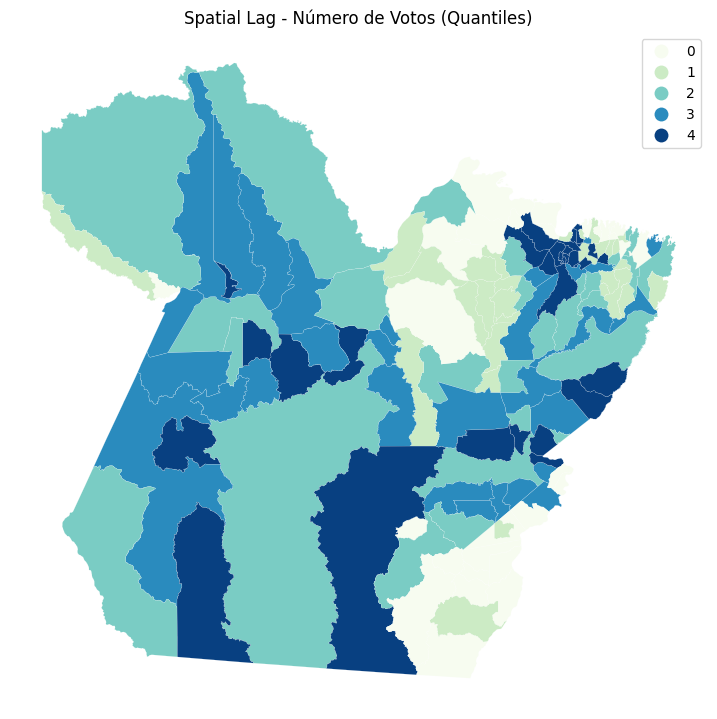

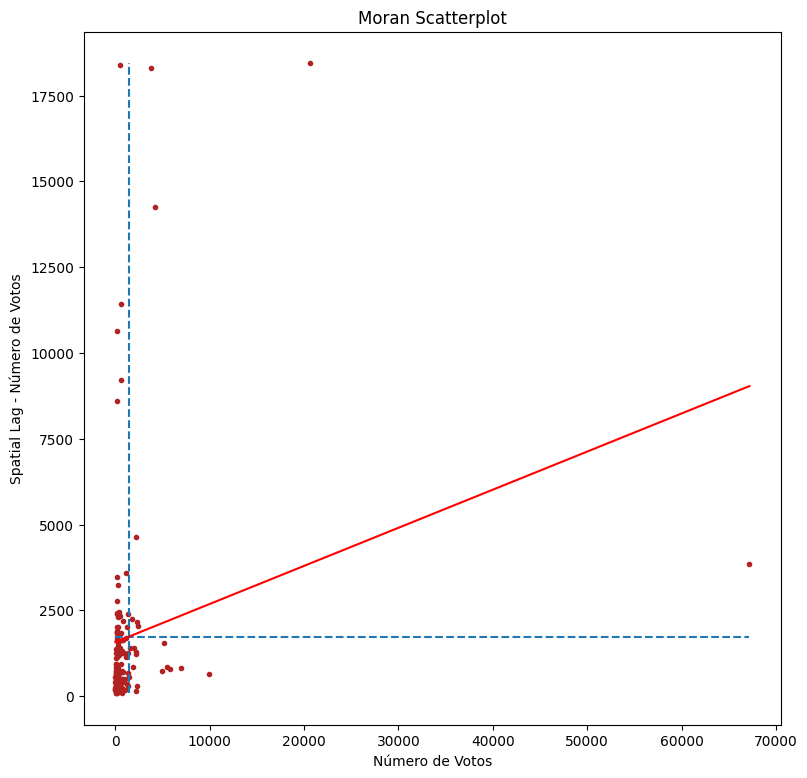

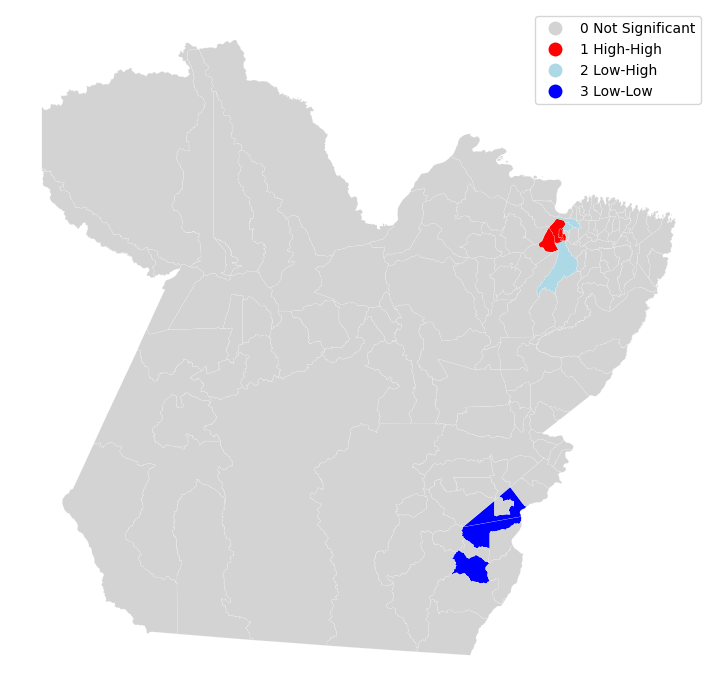

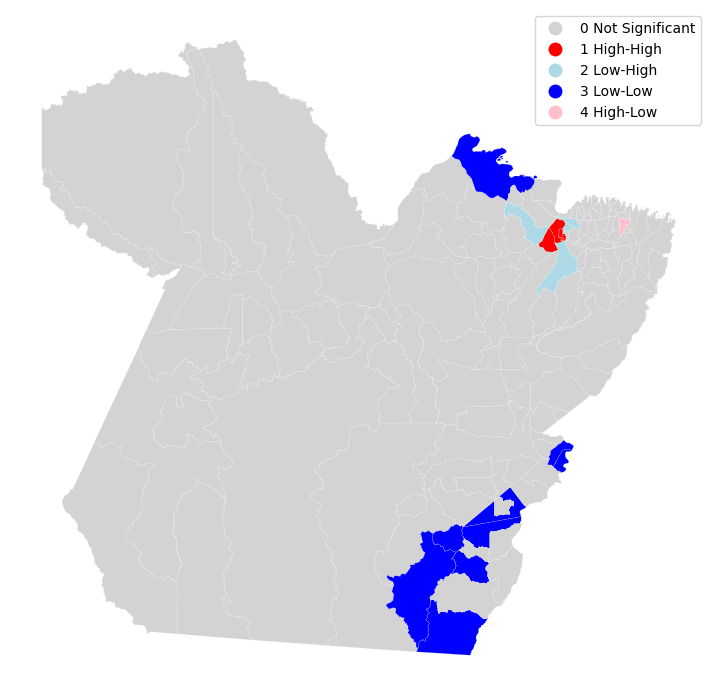

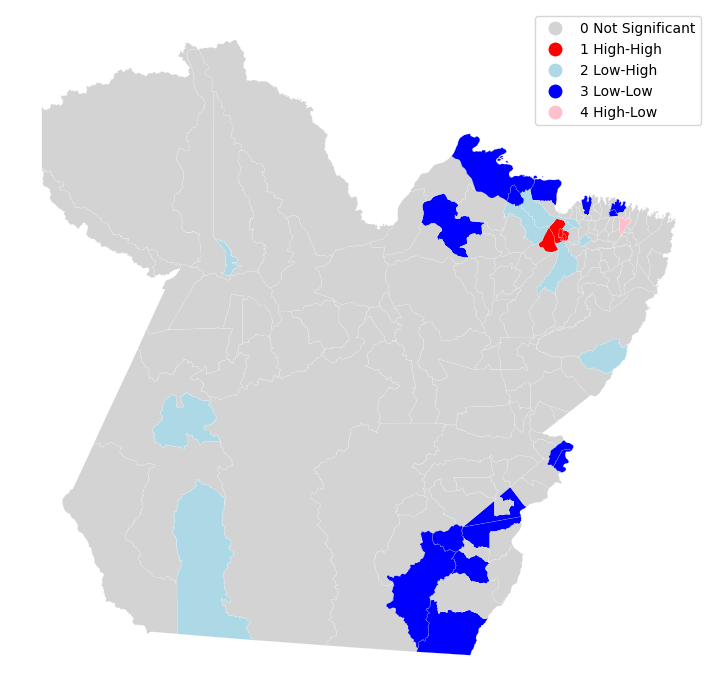

In [63]:
plot_all_municipio('EDER MAURO CARDOSO BARRA')

/tmp/ipykernel_8642/409921656.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


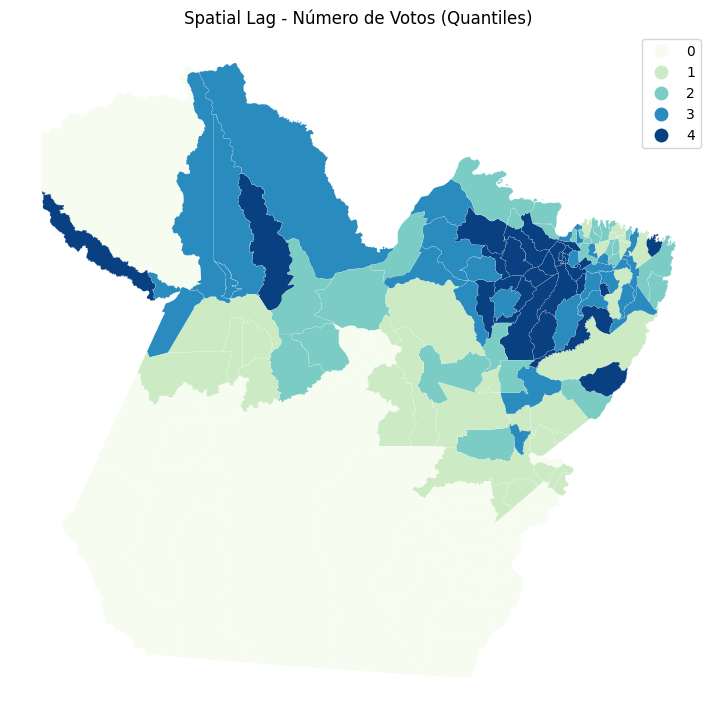

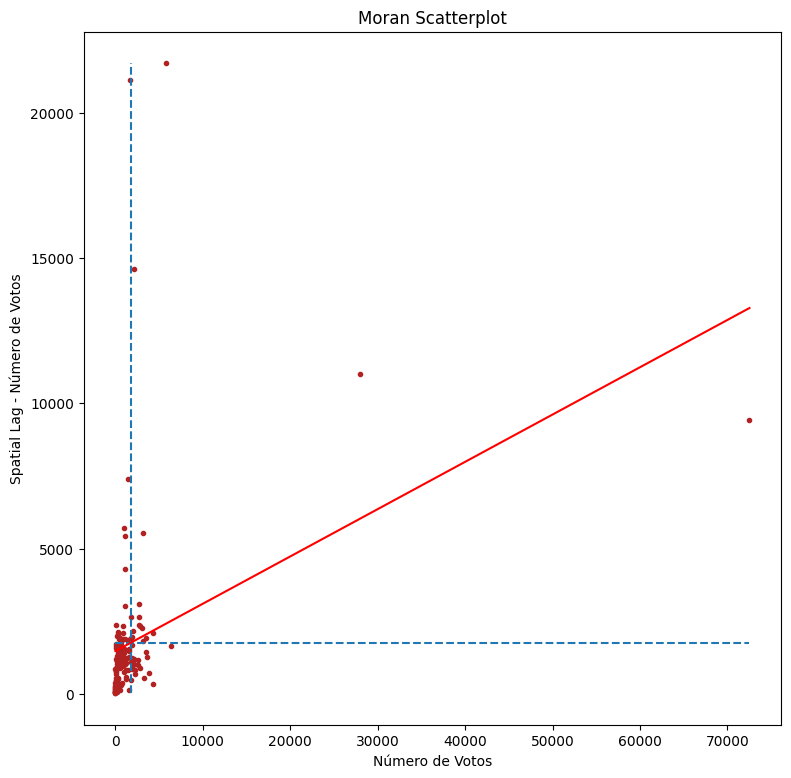

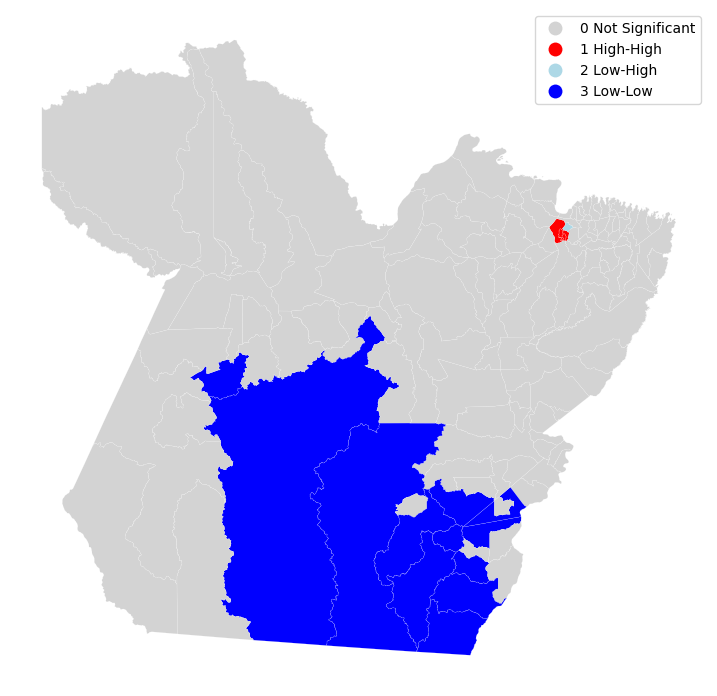

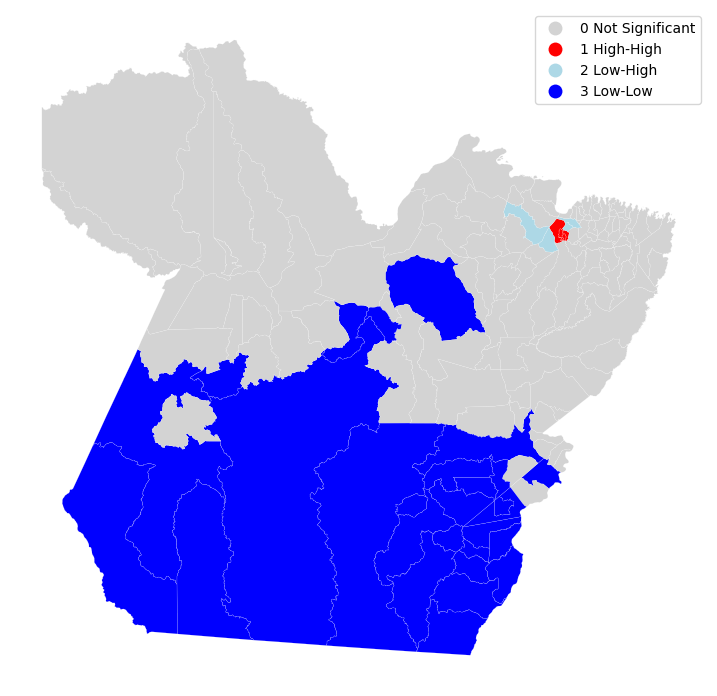

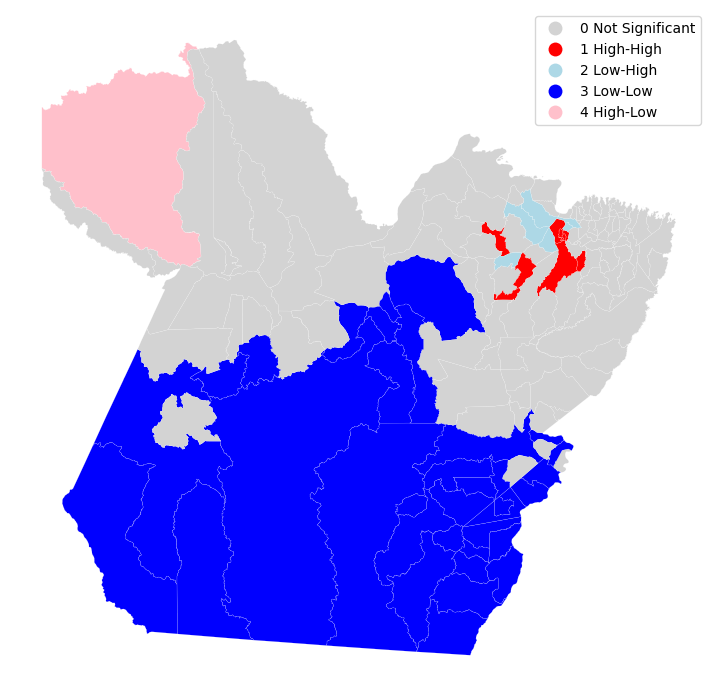

In [64]:
plot_all_municipio('ALESSANDRA HABER CARVALHO SANTOS')

/tmp/ipykernel_8642/409921656.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


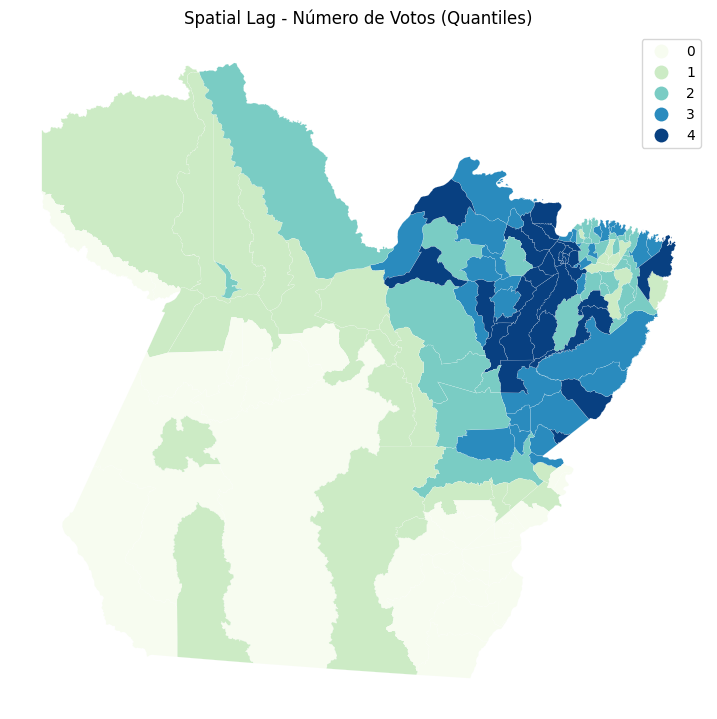

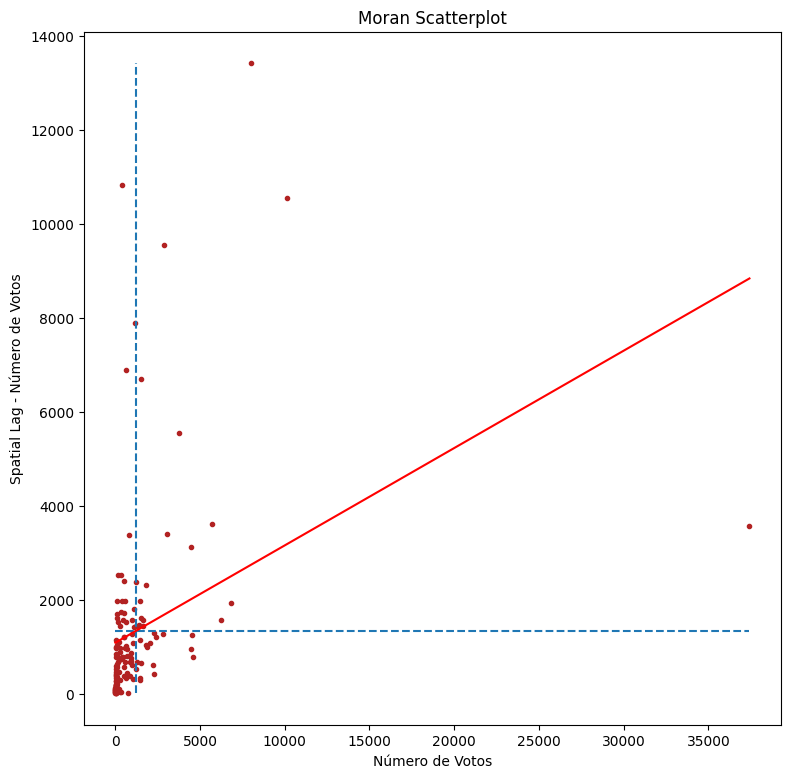

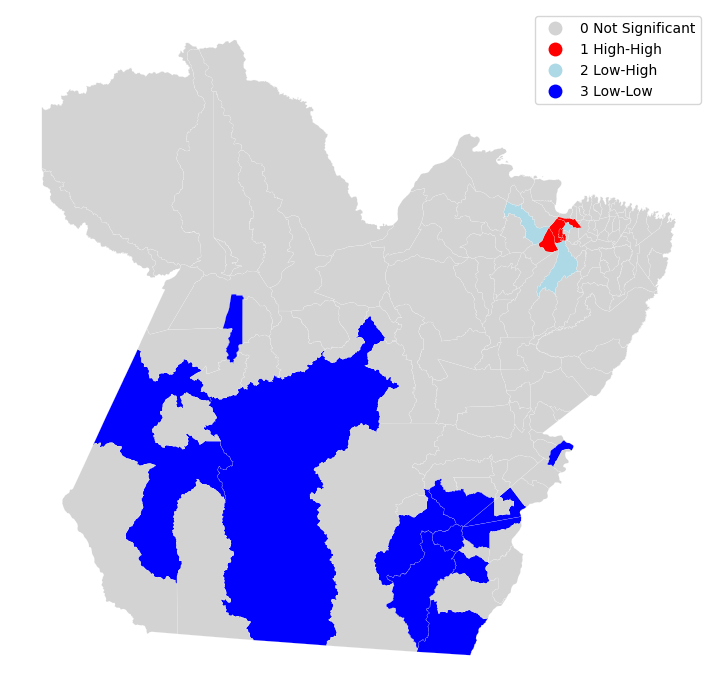

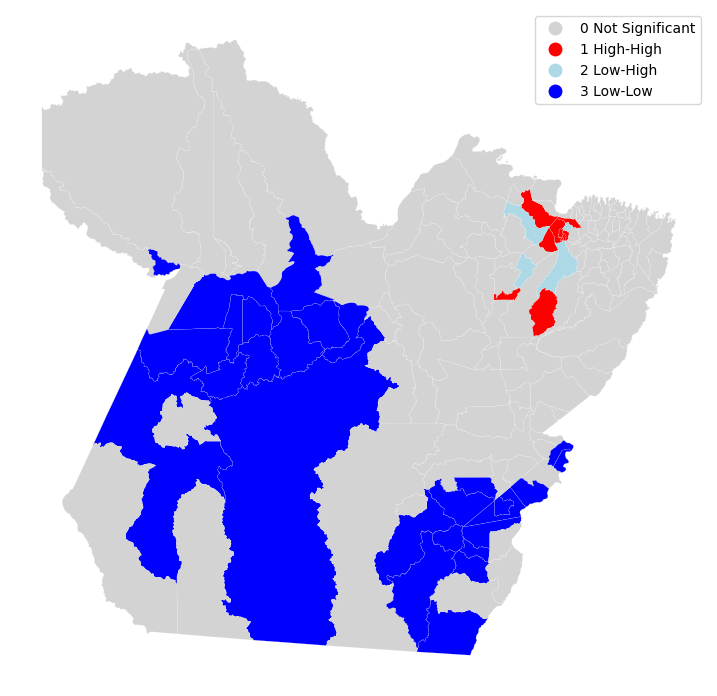

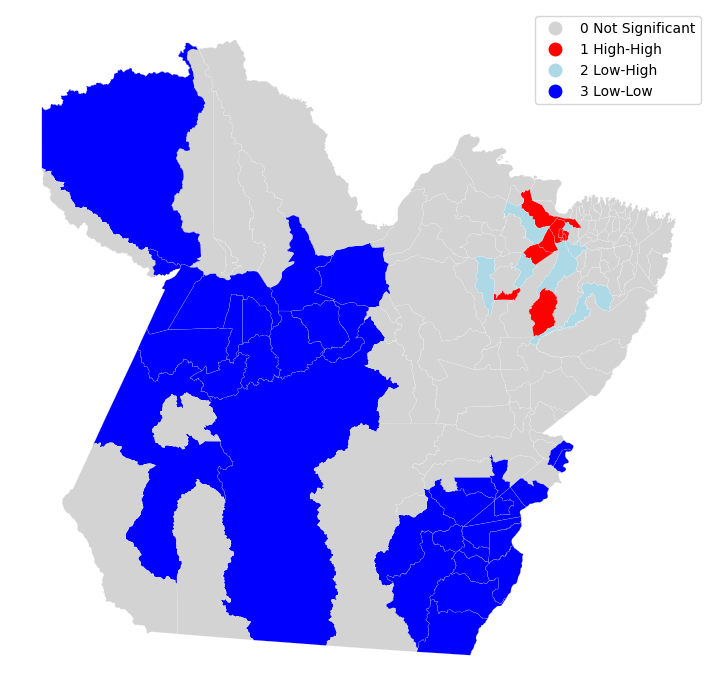

In [65]:
plot_all_municipio('ELCIONE THEREZINHA ZAHLUTH BARBALHO')

/tmp/ipykernel_8642/409921656.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


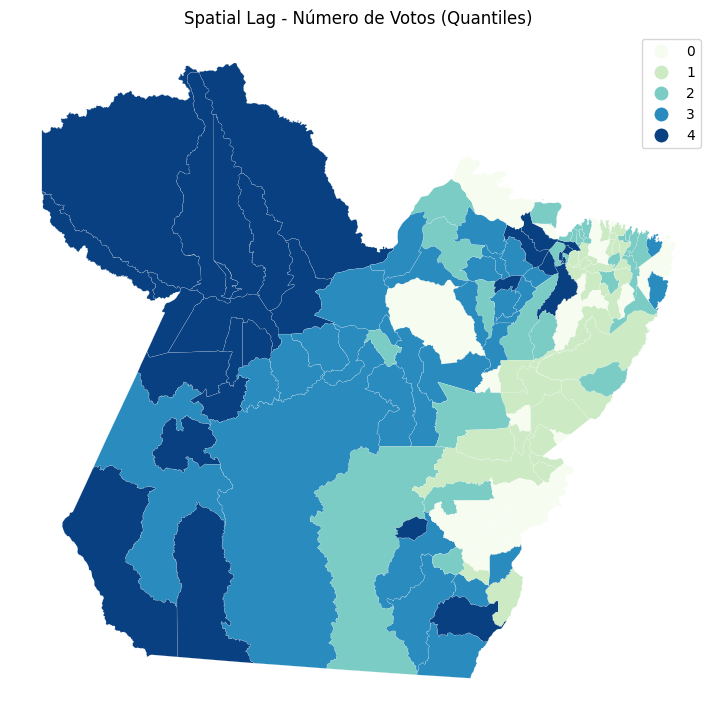

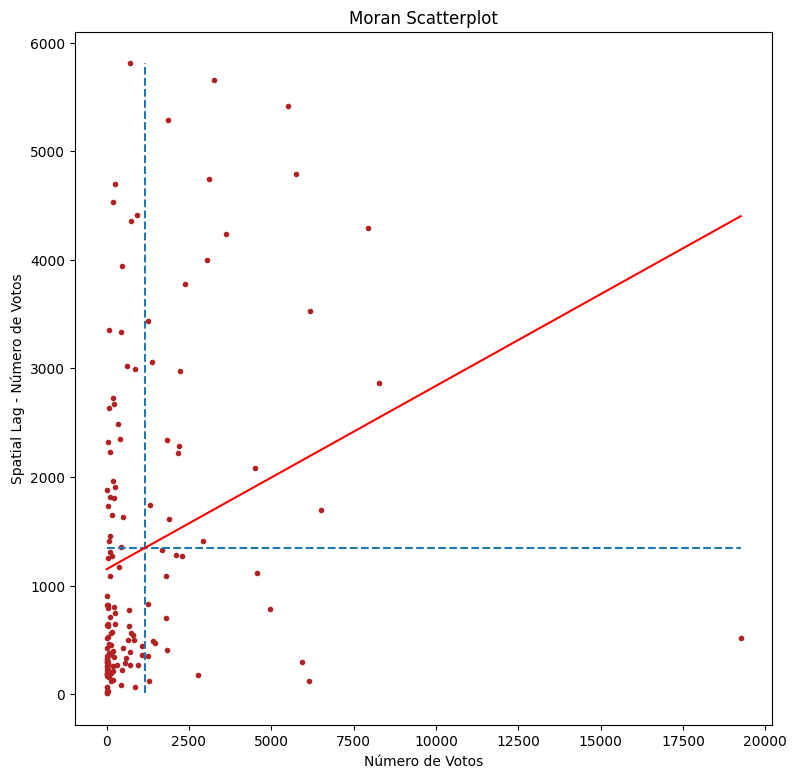

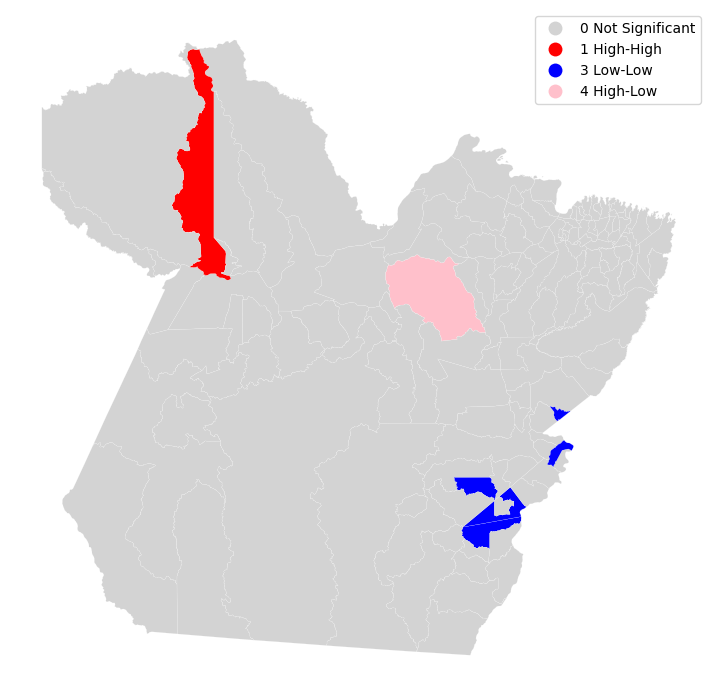

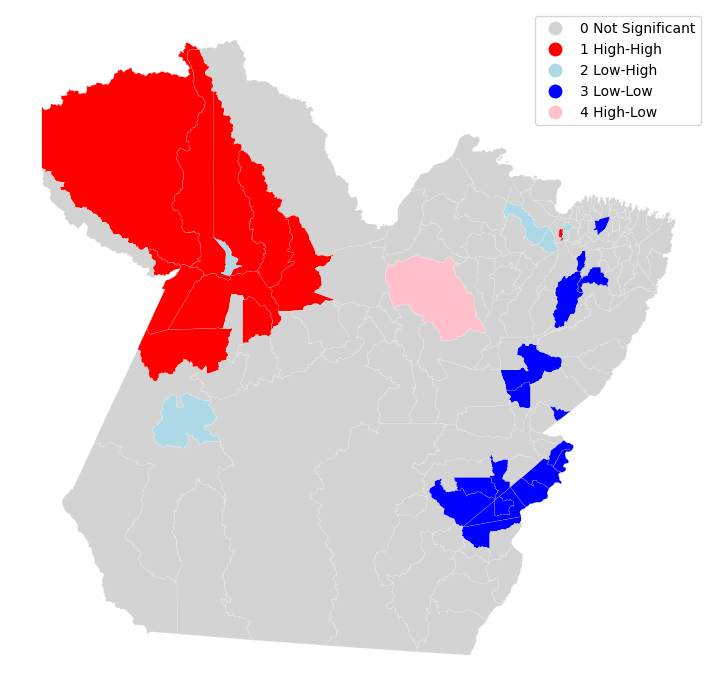

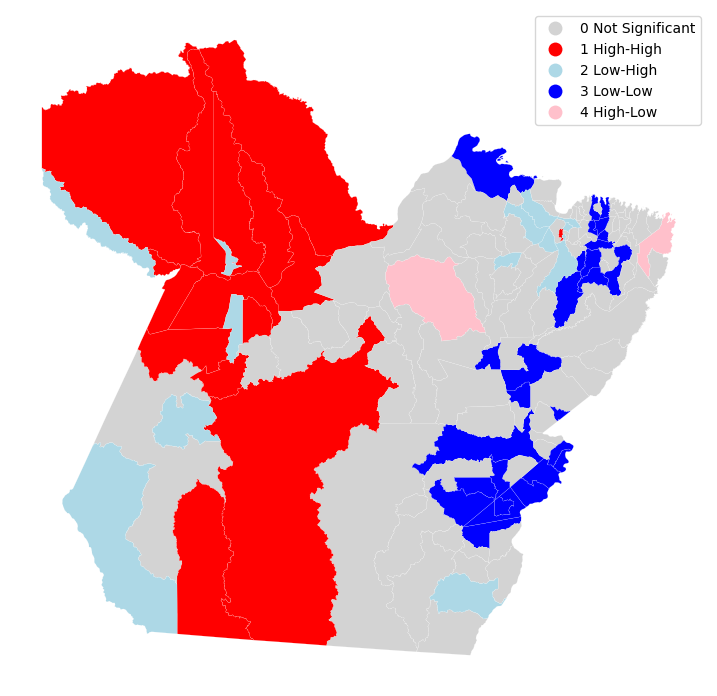

In [67]:
plot_all_municipio('JOSE BENITO PRIANTE JUNIOR')

/tmp/ipykernel_8642/409921656.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


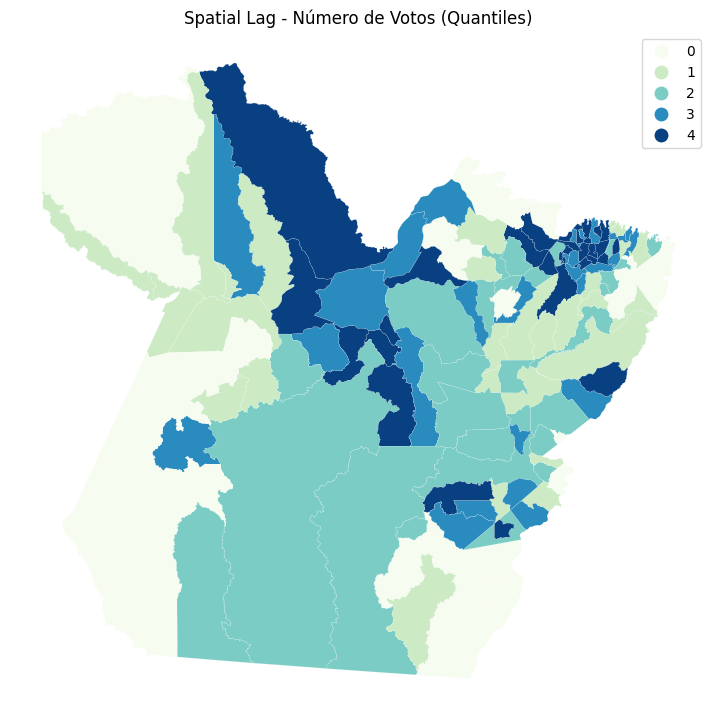

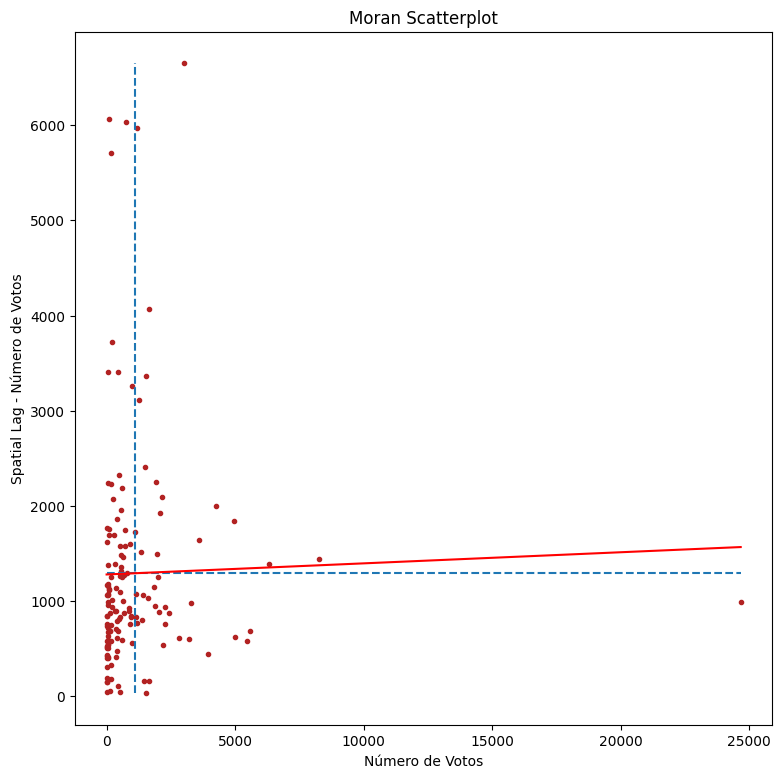

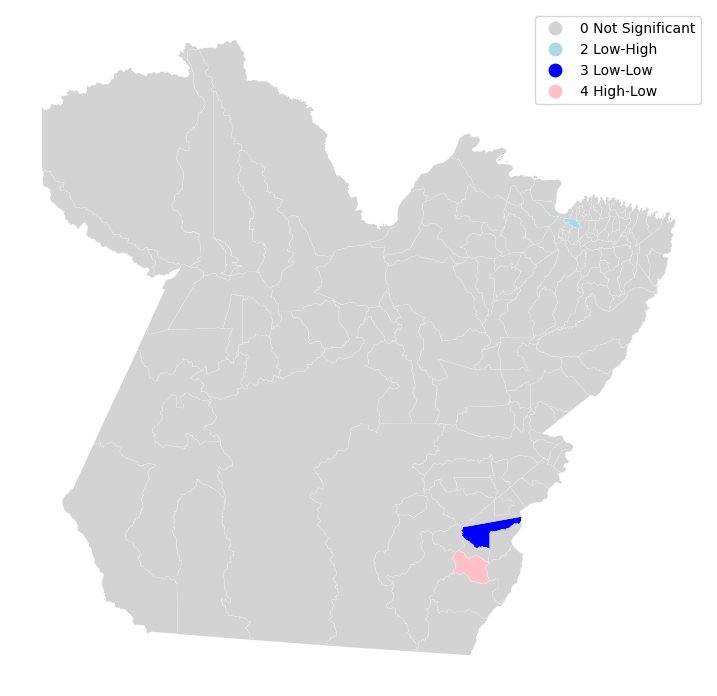

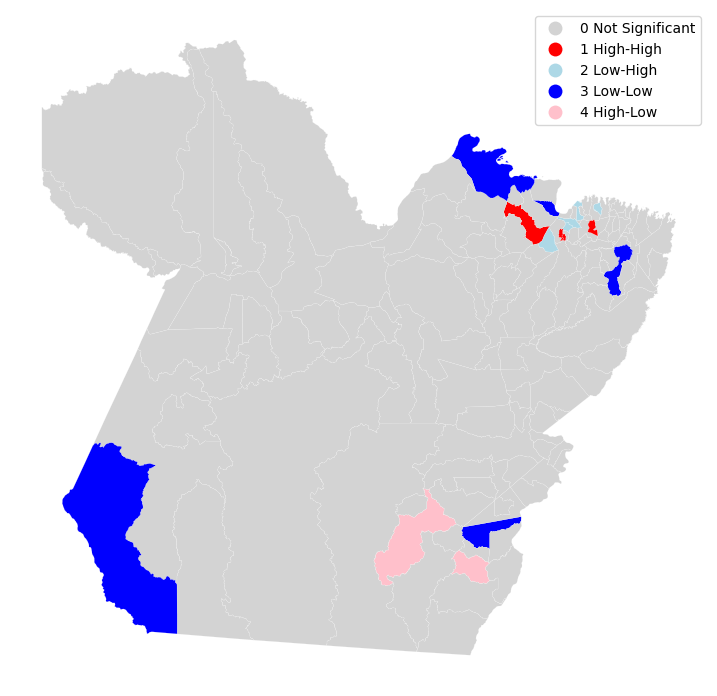

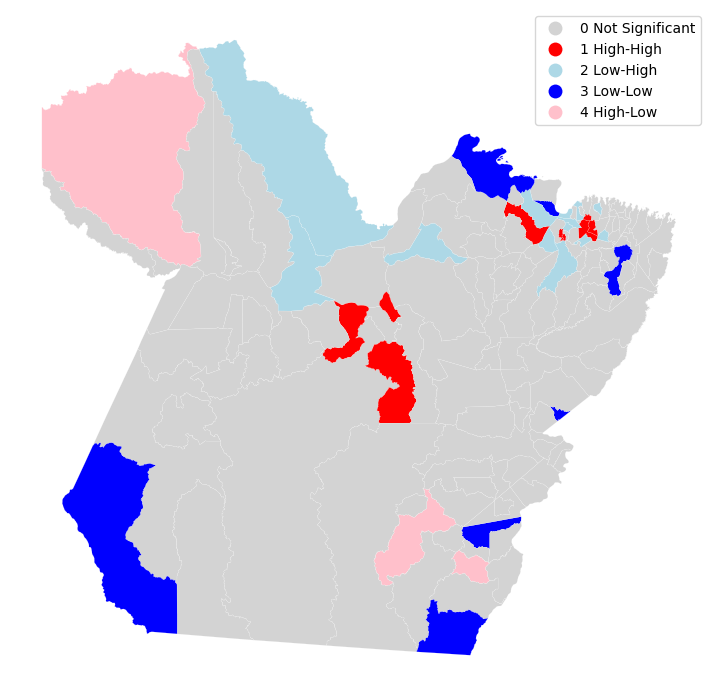

In [66]:
plot_all_municipio('RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE')

# Autocorrelação espacial global

In [71]:
df = gdf

#### Agrupando em microregiões

In [139]:
dados = {
    "Óbidos": ['Faro', 'Juruti', 'Óbidos', 'Oriximiná', 'Terra Santa'],
    "Santarem": ['Alenquer', 'Belterra', 'Curuá', 'Mojuí dos Campos', 'Monte Alegre', 'Placas', 'Prainha', 'Santarém'],
    'Almeirim': ['Almeirim', 'Porto de Moz'],
    'Portel': ['Bagre', 'Gurupá', 'Melgaço', 'Portel'],
    'Furos de Breves': ['Afuá', 'Anajás', 'Breves', 'Curralinho', 'São Sebastião da Boa Vista'],
    'Arari': ['Cachoeira do Arari', 'Chaves', 'Muaná', 'Ponta de Pedras', 'Salvaterra', 'Santa Cruz do Arari', 'Soure'],
    'Belém': ['Ananindeua', 'Barcarena', 'Belém', 'Benevides', 'Marituba', 'Santa Bárbara do Pará'],
    'Castanhal': ['Bujaru', 'Castanhal', 'Inhangapi', 'Santa Izabel do Pará', 'Santo Antônio do Tauá'],
    'Salgado': ['Colares', 'Curuçá', 'Magalhães Barata', 'Maracanã', 'Marapanim', 'Salinópolis', 'São Caetano de Odivelas', 'São João da Ponta', 'São João de Pirabas', 'Terra Alta', 'Vigia'],
    'Bragantina': ['Augusto Corrêa', 'Bonito', 'Bragança', 'Capanema', 'Igarapé-Açu', 'Nova Timboteua', 'Peixe-Boi', 'Primavera', 'Quatipuru', 'Santa Maria do Pará', 'Santarém Novo', 'São Francisco do Pará', 'Tracuateua'],
    'Cametá': ['Abaetetuba', 'Baião', 'Cametá', 'Igarapé-Miri', 'Limoeiro do Ajuru', 'Mocajuba', 'Oeiras do Pará'],
    'Tomé-Açu': ['Acará', 'Concórdia do Pará', 'Moju', 'Tailândia', 'Tomé-Açu'],
    'Guamá': ['Aurora do Pará', 'Cachoeira do Piriá', 'Capitão Poço', 'Garrafão do Norte', 'Ipixuna do Pará', 'Irituia', 'Mãe do Rio', 'Nova Esperança do Piriá', 'Ourém', 'Santa Luzia do Pará', 'São Domingos do Capim', 'São Miguel do Guamá', 'Viseu'],
    'Itaituba': ['Aveiro', 'Itaituba', 'Jacareacanga', 'Novo Progresso', 'Rurópolis', 'Trairão'],
    'Altamira': ['Altamira', 'Anapu', 'Brasil Novo', 'Medicilândia', 'Pacajá', 'Senador José Porfírio', 'Uruará', 'Vitória do Xingu'],
    'Tucuruí': ['Breu Branco', 'Itupiranga', 'Jacundá', 'Nova Ipixuna', 'Novo Repartimento', 'Tucuruí'],
    'Paragominas': ['Abel Figueiredo', 'Bom Jesus do Tocantins', 'Dom Eliseu', 'Goianésia do Pará', 'Paragominas', 'Rondon do Pará', 'Ulianópolis'],
    'São Félix do Xingu': ['Bannach', 'Cumaru do Norte', 'Ourilândia do Norte', 'São Félix do Xingu', 'Tucumã'],
    'Parauapebas': ['Água Azul do Norte', 'Canaã dos Carajás', 'Curionópolis', 'Eldorado do Carajás', 'Parauapebas'],
    'Marabá': ['Brejo Grande do Araguaia', 'Marabá', 'Palestina do Pará', 'São Domingos do Araguaia', 'São João do Araguaia'],
    'Redenção': [	"Pau D Arco", 'Piçarra', 'Redenção', 'Rio Maria', 'São Geraldo do Araguaia', 'Sapucaia', 'Xinguara'],
    'Conceição do Araguaia': ['Conceição do Araguaia', 'Floresta do Araguaia', 'Santa Maria das Barreiras', 'Santana do Araguaia']
}

In [144]:
print(pd.DataFrame({ "microrregião": dados.keys(), "municípios": dados.values()}).to_latex())

\begin{tabular}{lll}
\toprule
 & microrregião & municípios \\
\midrule
0 & Óbidos & ['Faro', 'Juruti', 'Óbidos', 'Oriximiná', 'Terra Santa'] \\
1 & Santarem & ['Alenquer', 'Belterra', 'Curuá', 'Mojuí dos Campos', 'Monte Alegre', 'Placas', 'Prainha', 'Santarém'] \\
2 & Almeirim & ['Almeirim', 'Porto de Moz'] \\
3 & Portel & ['Bagre', 'Gurupá', 'Melgaço', 'Portel'] \\
4 & Furos de Breves & ['Afuá', 'Anajás', 'Breves', 'Curralinho', 'São Sebastião da Boa Vista'] \\
5 & Arari & ['Cachoeira do Arari', 'Chaves', 'Muaná', 'Ponta de Pedras', 'Salvaterra', 'Santa Cruz do Arari', 'Soure'] \\
6 & Belém & ['Ananindeua', 'Barcarena', 'Belém', 'Benevides', 'Marituba', 'Santa Bárbara do Pará'] \\
7 & Castanhal & ['Bujaru', 'Castanhal', 'Inhangapi', 'Santa Izabel do Pará', 'Santo Antônio do Tauá'] \\
8 & Salgado & ['Colares', 'Curuçá', 'Magalhães Barata', 'Maracanã', 'Marapanim', 'Salinópolis', 'São Caetano de Odivelas', 'São João da Ponta', 'São João de Pirabas', 'Terra Alta', 'Vigia'] \\
9 & Bragant

In [72]:
from shapely.ops import unary_union

In [73]:
microregiao_df = pd.DataFrame()

In [74]:
for microregion, muns in dados.items():
    df_micro = df[df['municipio_id'].isin(muns)]
    df_micro['microregiao'] = microregion
    groups = df_micro.groupby(['candidado', 'microregiao'])
    df_grouped = groups['num_votos'].sum().reset_index().sort_values('num_votos', ascending=False)

    new_geom = unary_union(gpd.GeoSeries(df_micro['geometry']))
    df_grouped['geometry'] = new_geom

    microregiao_df = pd.concat([microregiao_df, df_grouped], ignore_index=True)

/home/daniel/.pyenv/versions/3.9.19/envs/env/lib/python3.9/site-packages/geopandas/geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/daniel/.pyenv/versions/3.9.19/envs/env/lib/python3.9/site-packages/geopandas/geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/daniel/.pyenv/versions/3.9.19/envs/env/lib/python3.9/site-packages/geopandas/geodataframe.py:1525: SettingWithCopyWarning: 
A value is tryin

In [75]:
microregiao_gdf = GeoDataFrame(microregiao_df)

In [77]:
def plot_all(candidate_name, p=[0.01, 0.05, 0.1]):
    gdf_k = microregiao_gdf[microregiao_gdf['candidado'] == candidate_name]
     
    df = gdf_k
    wq =  lps.weights.Queen.from_dataframe(df)
    wq.transform = 'r'
    
    y = df['num_votos']
    ylag = lps.weights.lag_spatial(wq, y)
    
    ylagq5 = mc.Quantiles(ylag, k=5)
    
    f, ax = plt.subplots(1, figsize=(9, 9))
    df.assign(cl=ylagq5.yb).plot(column='cl', categorical=True, \
            k=5, cmap='GnBu', linewidth=0.1, ax=ax, \
            edgecolor='white', legend=True)
    ax.set_axis_off()
    plt.title("Spatial Lag - Número de Votos (Quantiles)")
    plt.savefig(f"./images/microregiao-numero-votos-{candidate_name}-spatial-lag.png", bbox_inches='tight')
    plt.show()

    wq.transform = 'r'
    lag_price = lps.weights.lag_spatial(wq, df['num_votos'])
    price = df['num_votos']
    b, a = np.polyfit(price, lag_price, 1)
    f, ax = plt.subplots(1, figsize=(9, 9))
    plt.plot(price, lag_price, '.', color='firebrick')
    plt.vlines(price.mean(), lag_price.min(), lag_price.max(), linestyle='--')
    plt.hlines(lag_price.mean(), price.min(), price.max(), linestyle='--')
    plt.plot(price, a + b*price, 'r')
    plt.title('Moran Scatterplot')
    plt.ylabel('Spatial Lag - Número de Votos')
    plt.xlabel('Número de Votos')
    plt.savefig(f"./images/microregiao-numero-votos-{candidate_name}-moran-scatterplot.png", bbox_inches='tight')
    plt.show()

    for _p in p:
        li = esda.moran.Moran_Local(y, wq)    
        sig = 1 * (li.p_sim < _p)
        hotspot = 1 * (sig * li.q==1)
        coldspot = 3 * (sig * li.q==3)
        doughnut = 2 * (sig * li.q==2)
        diamond = 4 * (sig * li.q==4)
        spots = hotspot + coldspot + doughnut + diamond
        spots
        
        spot_labels = [ '0 Not Significant', '1 High-High', '2 Low-High', '3 Low-Low', '4 High-Low']
        colors_names = [ 'lightgrey', 'red', 'lightblue', 'blue', 'pink']

        spots_unique = set(spots)
        colors_names = [colors_names[i] for i in spots_unique]

        labels = [spot_labels[i] for i in spots]
        
        hmap = colors.ListedColormap(colors_names)
        f, ax = plt.subplots(1, figsize=(9, 9))
        df.assign(cl=labels).plot(column='cl',categorical=True, \
                k=2, cmap=hmap, linewidth=0.1, ax=ax, \
                edgecolor='white', legend=True)
        ax.set_axis_off()
        plt.savefig(f"./images/microregiao-numero-votos-{candidate_name}-{_p}-moran.png", bbox_inches='tight')
        plt.show()

/tmp/ipykernel_8642/1019267747.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


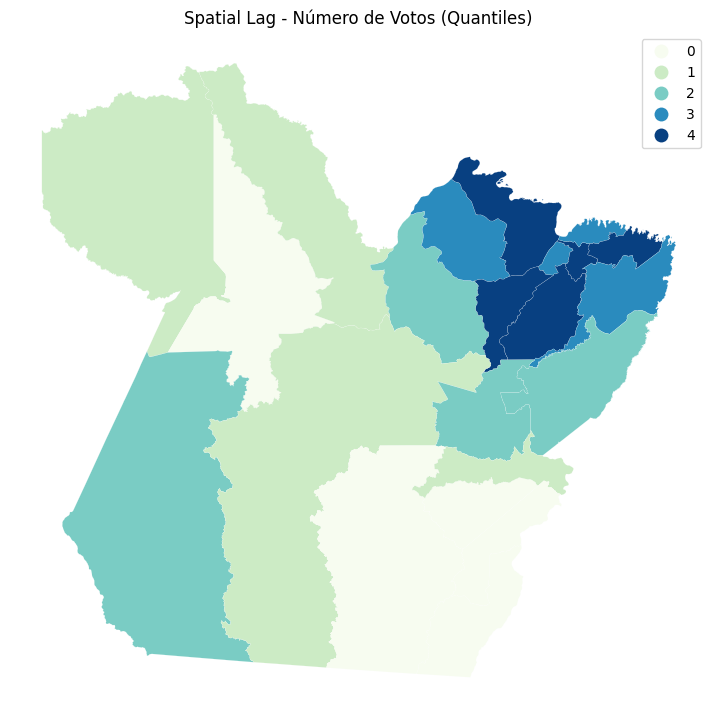

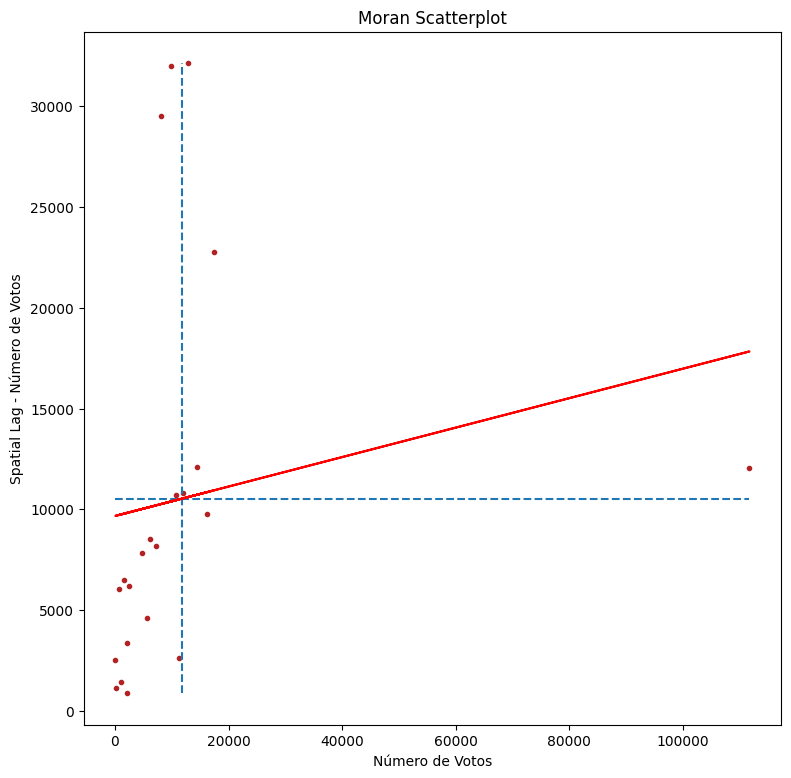

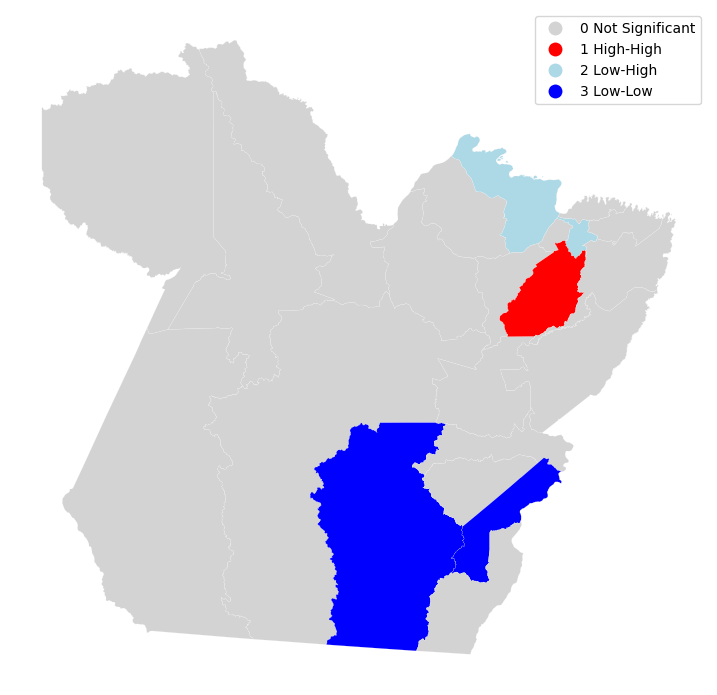

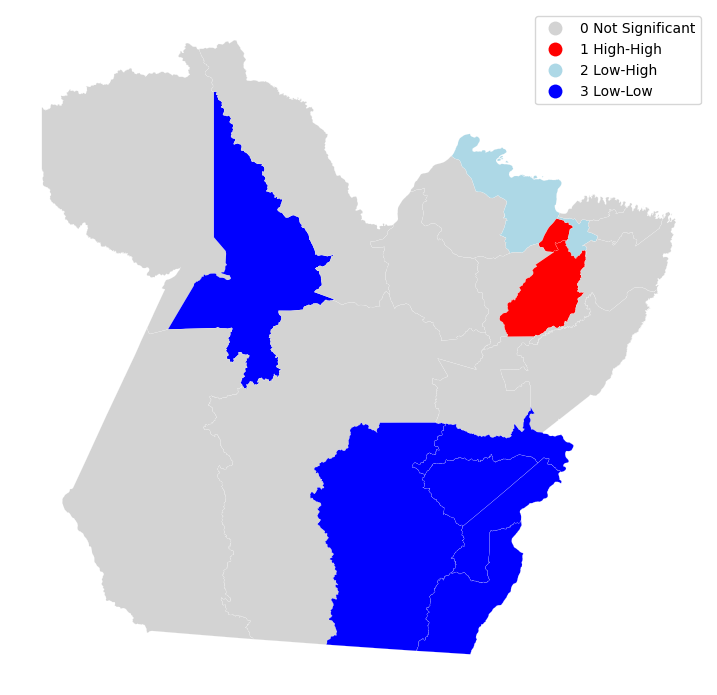

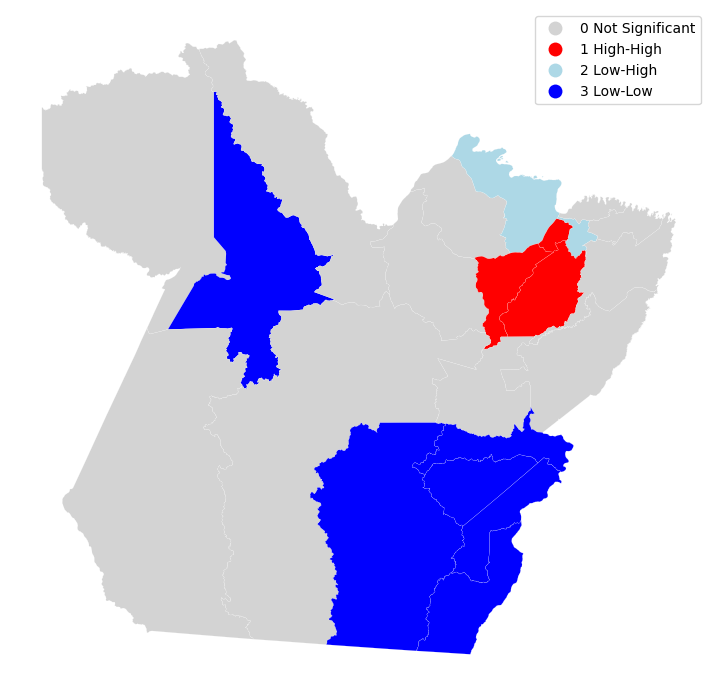

/tmp/ipykernel_8642/1019267747.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


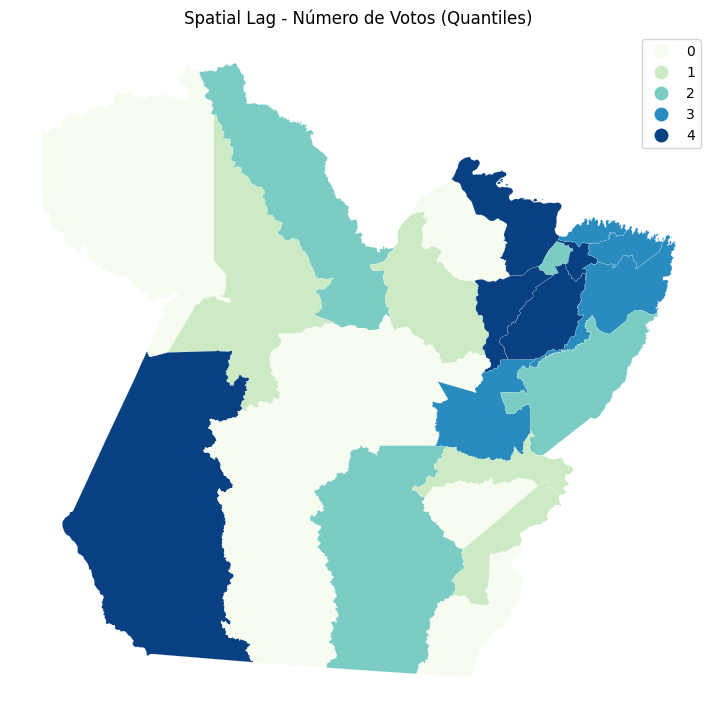

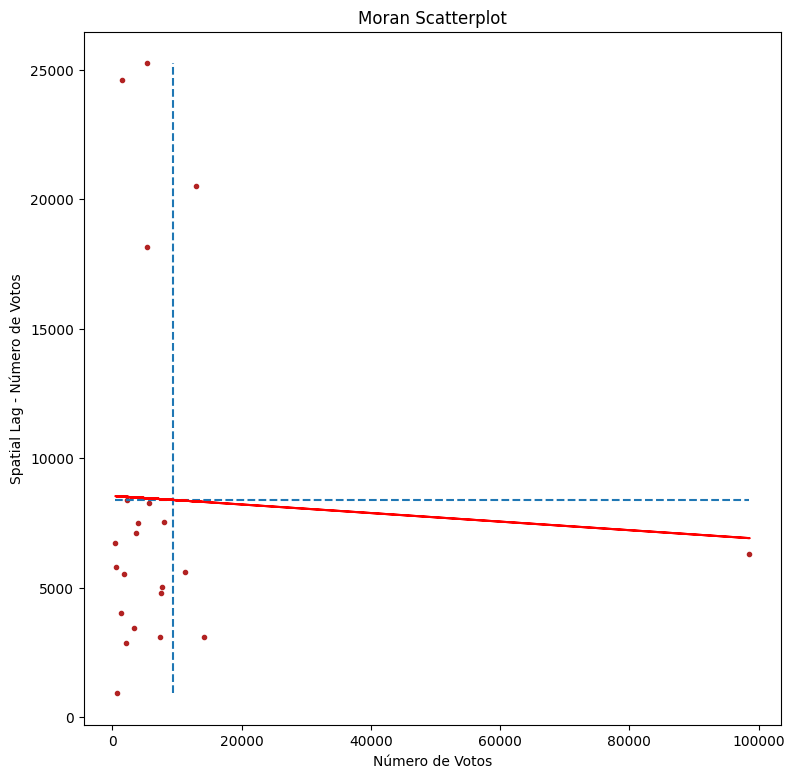

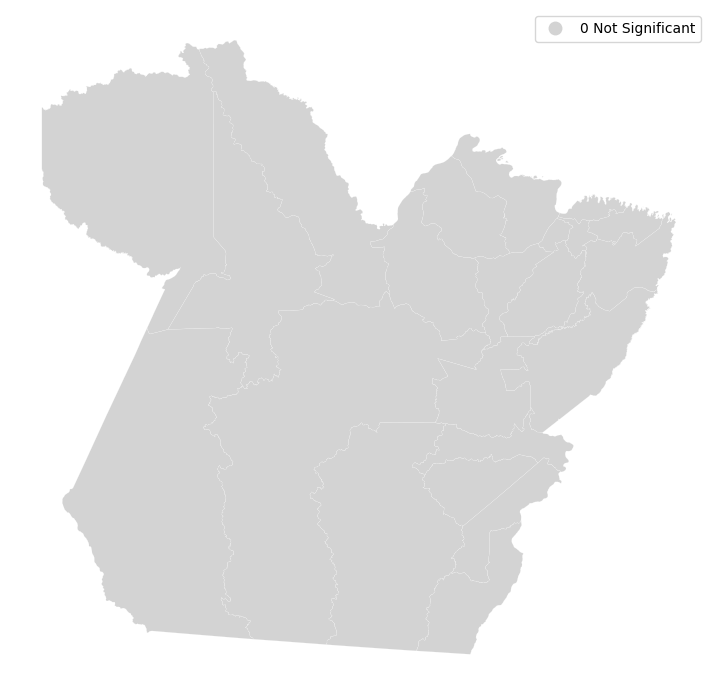

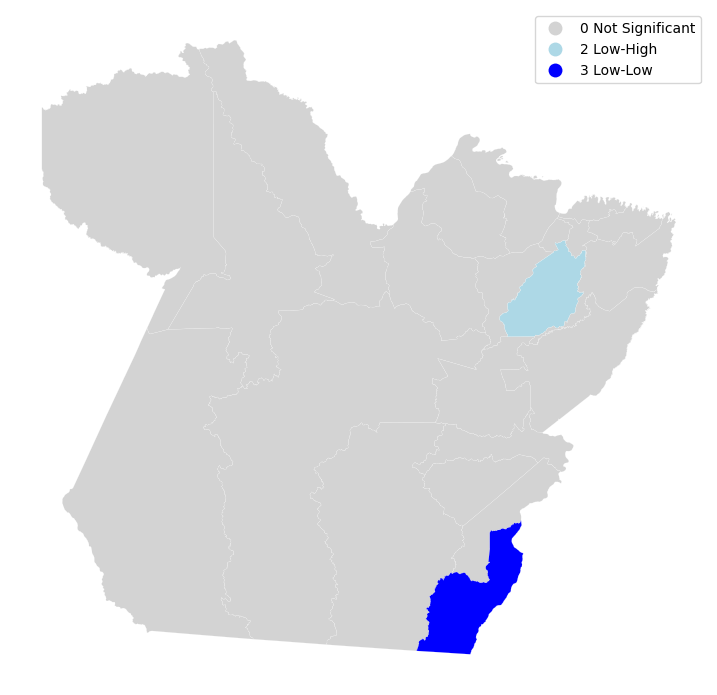

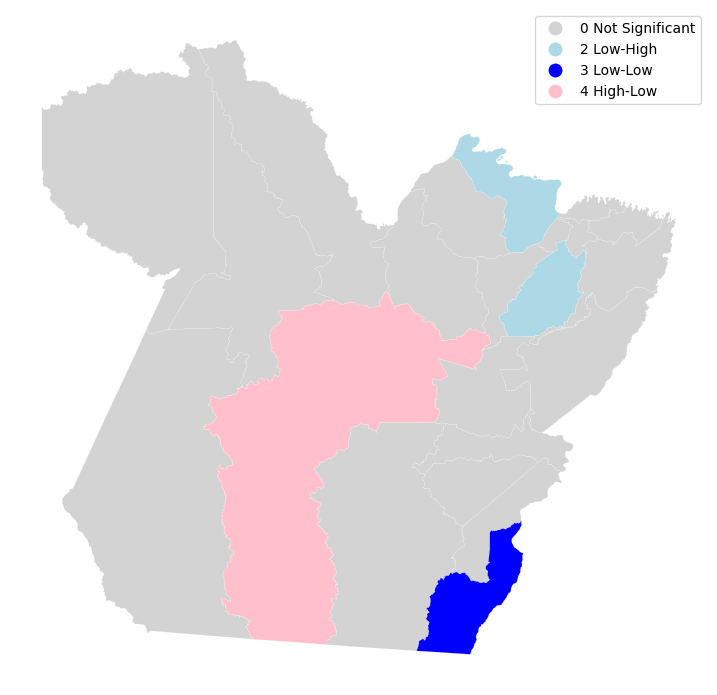

/tmp/ipykernel_8642/1019267747.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


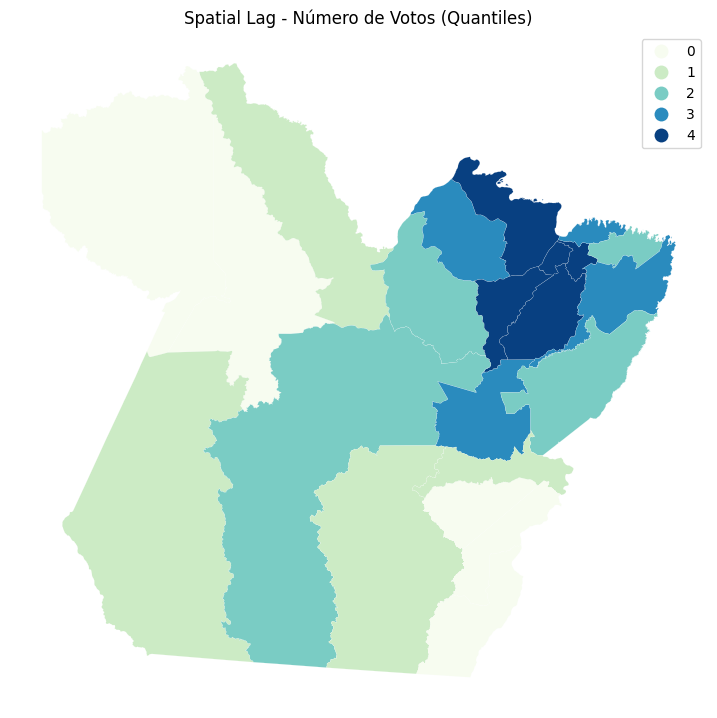

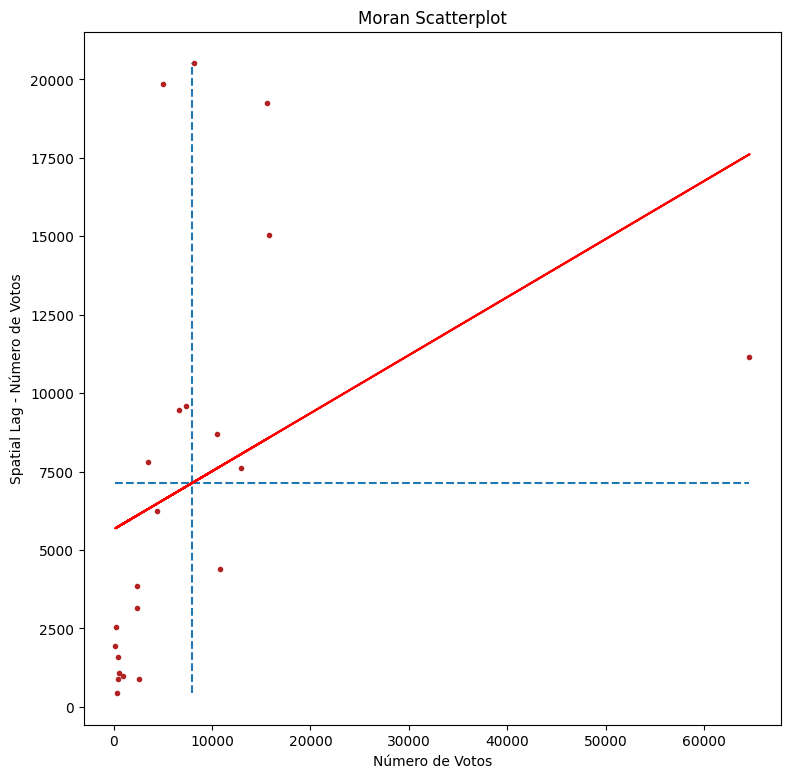

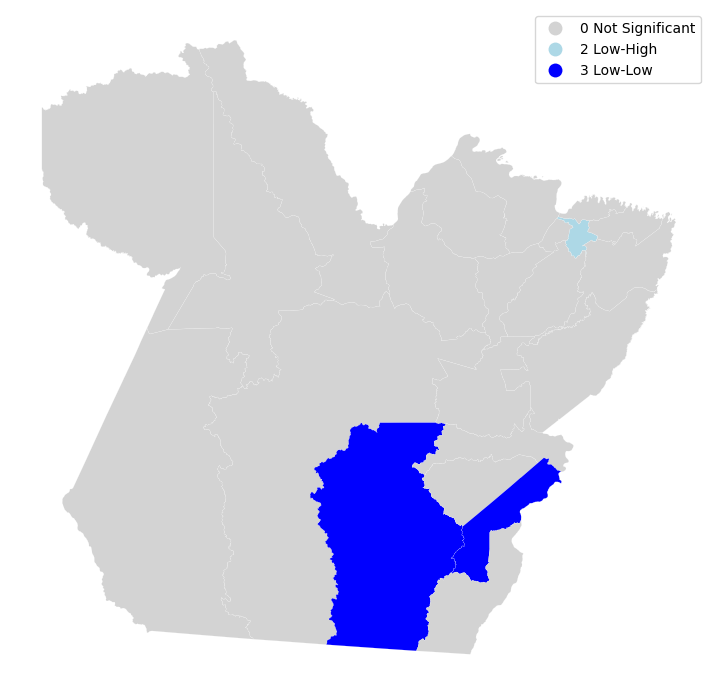

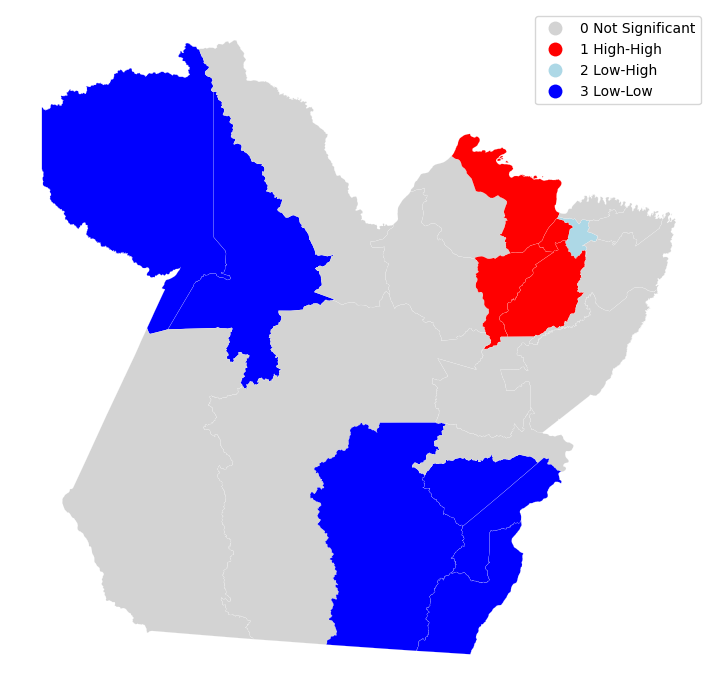

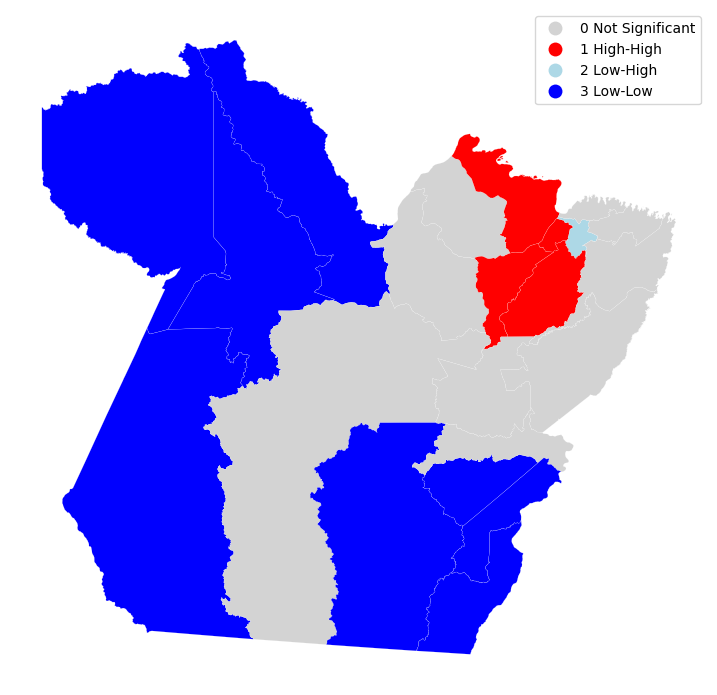

/tmp/ipykernel_8642/1019267747.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


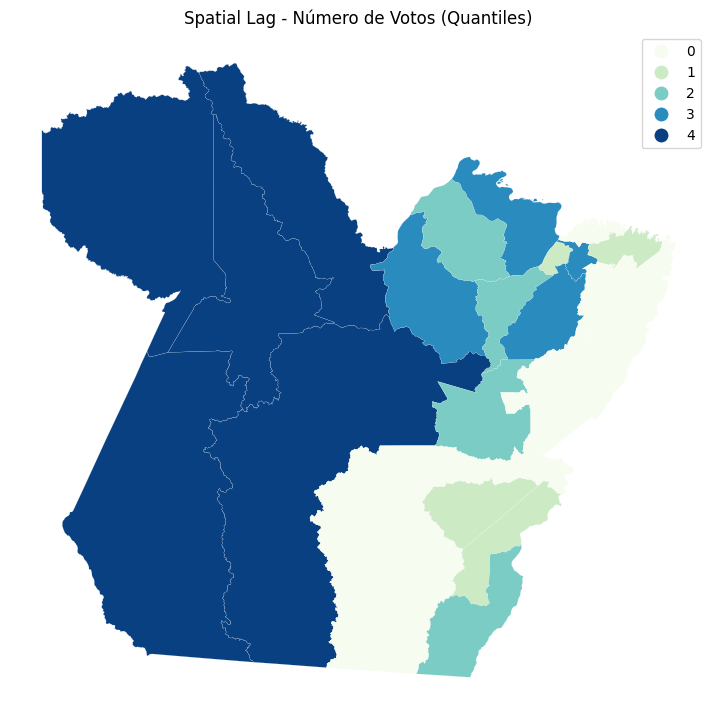

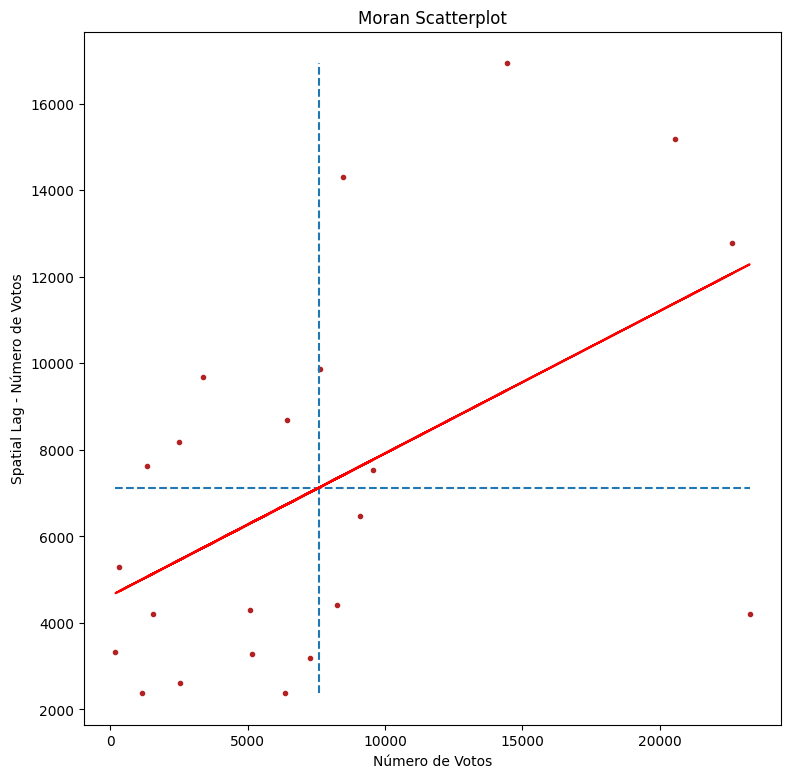

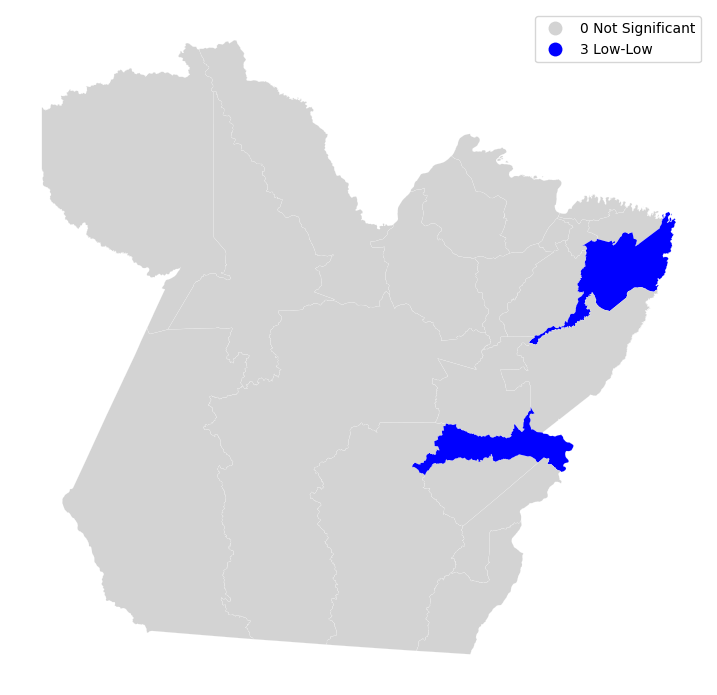

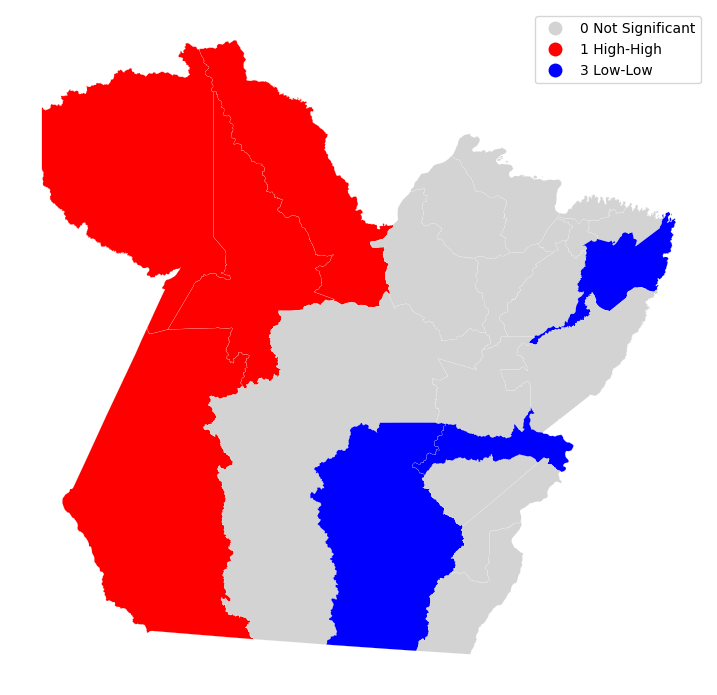

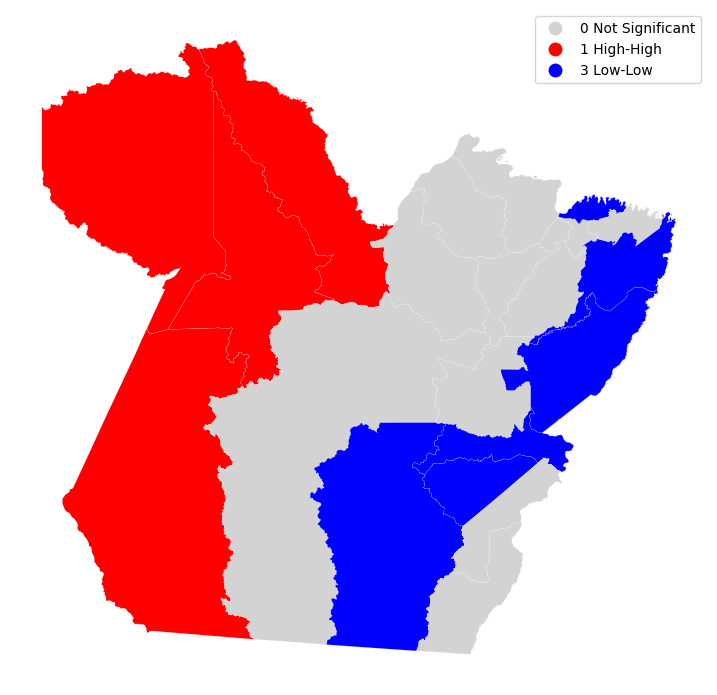

/tmp/ipykernel_8642/1019267747.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


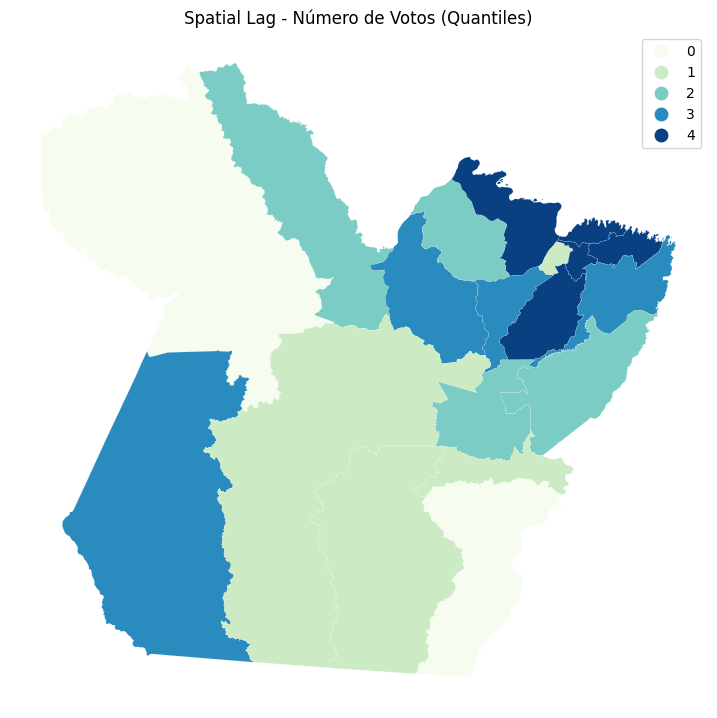

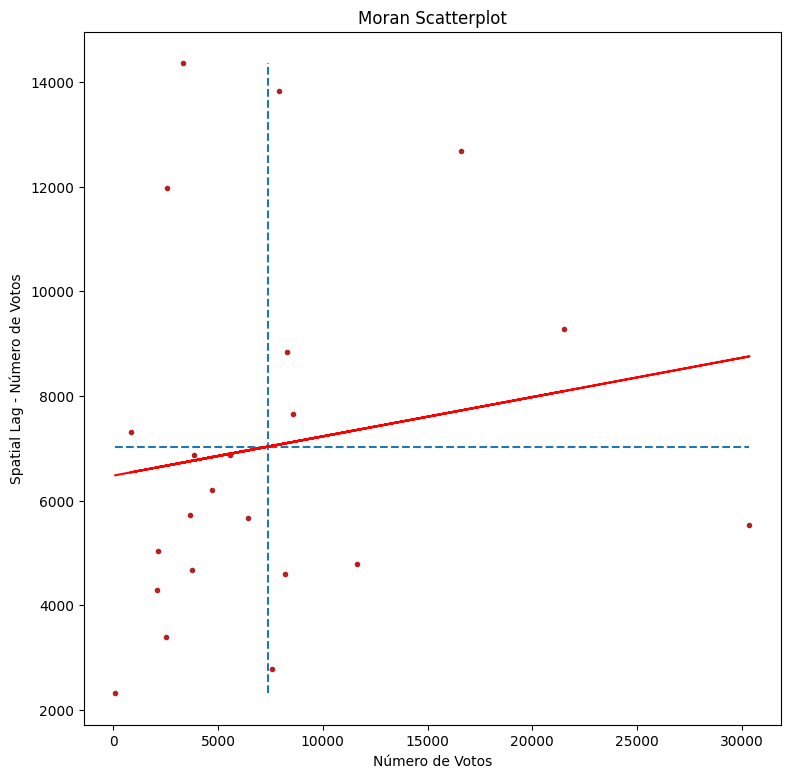

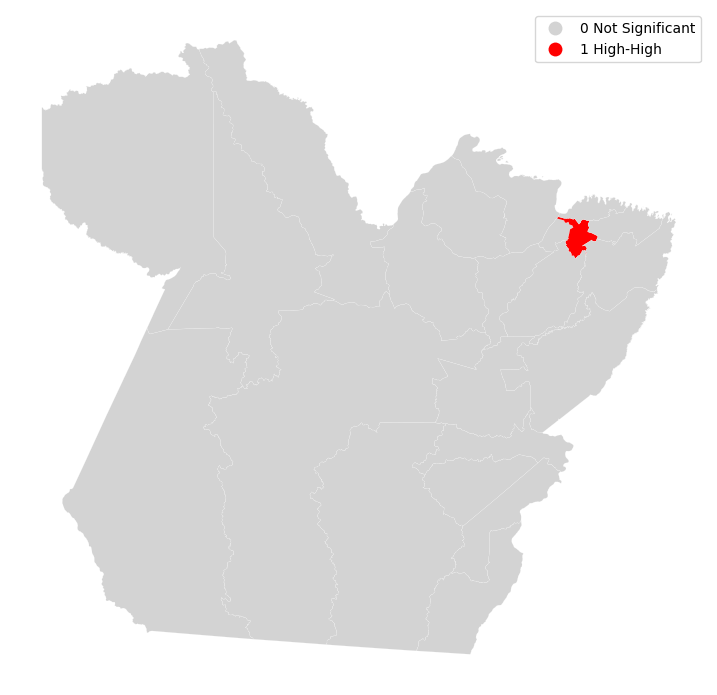

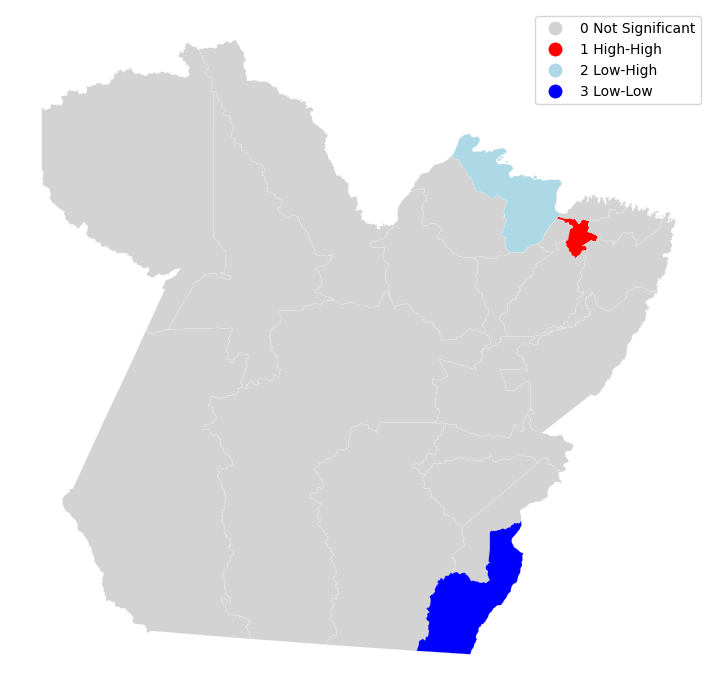

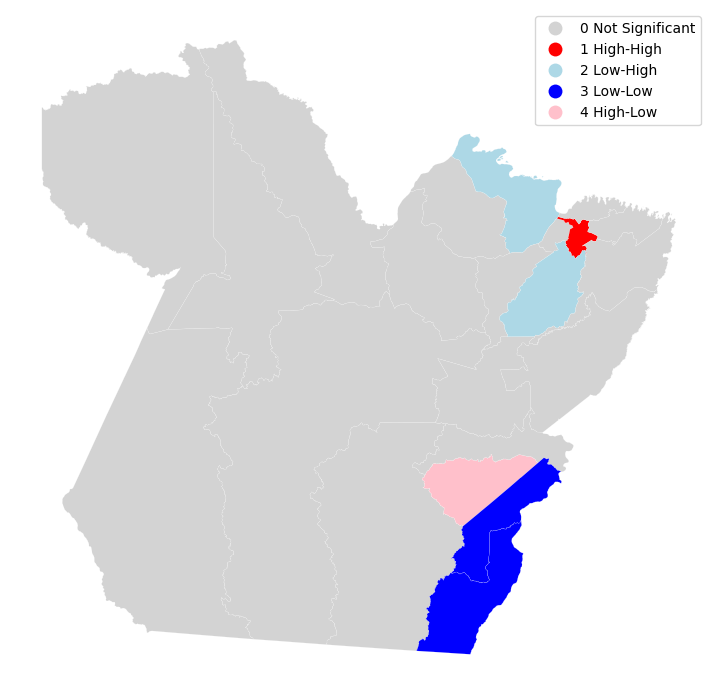

In [79]:
top_5_candidatos = [
    'ALESSANDRA HABER CARVALHO SANTOS',
    'EDER MAURO CARDOSO BARRA',
    'ELCIONE THEREZINHA ZAHLUTH BARBALHO',
    'JOSE BENITO PRIANTE JUNIOR',
    'RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE'
]
for c in top_5_candidatos:
    plot_all(c)

# Correlação - dados socioeconômicos

In [ ]:
# caracteristicas das cidades onde o candidato foi votado mais de 20% -> agregar info socioeconomicos    num_votos candidato por cidade - dados por cidade

In [81]:
import numpy as np
import scipy.stats

In [95]:
top_5_candidatos = [
    'ALESSANDRA HABER CARVALHO SANTOS',
    'EDER MAURO CARDOSO BARRA',
    'ELCIONE THEREZINHA ZAHLUTH BARBALHO',
    'JOSE BENITO PRIANTE JUNIOR',
    'RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE'
]

indices = {
    "taxa_natalidade": [],
    "idade_0_a_4": [],
    "idade_5_a_9": [],
    "idade_10_a_14": [],
    "idade_15_a_19": [],
    "idade_20_a_29": [],
    "idade_30_a_39": [],
    "idade_40_a_49": [],
    "idade_50_a_59": [],
    "idade_60_a_69": [],
    "idade_70_a_79": [],
    "idade_acima_80": [],
}


for c in top_5_candidatos:
    dados = engine.execute(f"""
    	select
    		cast(vc.num_votos as float) / (select sum(num_votos) from voto_candidato where m.id = voto_candidato.id_municipio) as perc_votos,
            dm.taxa_natalidade,
            dm.idade_0_a_4,
            dm.idade_5_a_9,
            dm.idade_10_a_14,
            dm.idade_15_a_19,
            dm.idade_20_a_29,
            dm.idade_30_a_39,
            dm.idade_40_a_49,
            dm.idade_50_a_59,
            dm.idade_60_a_69,
            dm.idade_70_a_79,
            dm.idade_acima_80
        from demografia_municipio dm
    	inner join municipio m on m.id = dm.id_municipio
    	inner join voto_candidato vc on vc.id_municipio = m.id
    	inner join candidato c on c.id = vc.id_candidato
    	where c.nome = '{c}'
        order by perc_votos desc
    	limit 10
    """).fetchall()
    x = [i[0] for i in dados]
    print(c)
    indices["taxa_natalidade"].append(scipy.stats.pearsonr(x, [i[1] for i in dados]).statistic)
    indices["idade_0_a_4"].append(scipy.stats.pearsonr(x, [i[2] for i in dados]).statistic)
    indices["idade_5_a_9"].append(scipy.stats.pearsonr(x, [i[3] for i in dados]).statistic)
    indices["idade_10_a_14"].append(scipy.stats.pearsonr(x, [i[4] for i in dados]).statistic)
    indices["idade_15_a_19"].append(scipy.stats.pearsonr(x, [i[5] for i in dados]).statistic)
    indices["idade_20_a_29"].append(scipy.stats.pearsonr(x, [i[6] for i in dados]).statistic)
    indices["idade_30_a_39"].append(scipy.stats.pearsonr(x, [i[7] for i in dados]).statistic)
    indices["idade_40_a_49"].append(scipy.stats.pearsonr(x, [i[8] for i in dados]).statistic)
    indices["idade_50_a_59"].append(scipy.stats.pearsonr(x, [i[9] for i in dados]).statistic)
    indices["idade_60_a_69"].append(scipy.stats.pearsonr(x, [i[10] for i in dados]).statistic)
    indices["idade_70_a_79"].append(scipy.stats.pearsonr(x, [i[11] for i in dados]).statistic)
    indices["idade_acima_80"].append(scipy.stats.pearsonr(x, [i[12] for i in dados]).statistic)
    print("=======================")

ALESSANDRA HABER CARVALHO SANTOS
EDER MAURO CARDOSO BARRA
ELCIONE THEREZINHA ZAHLUTH BARBALHO
JOSE BENITO PRIANTE JUNIOR
RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE


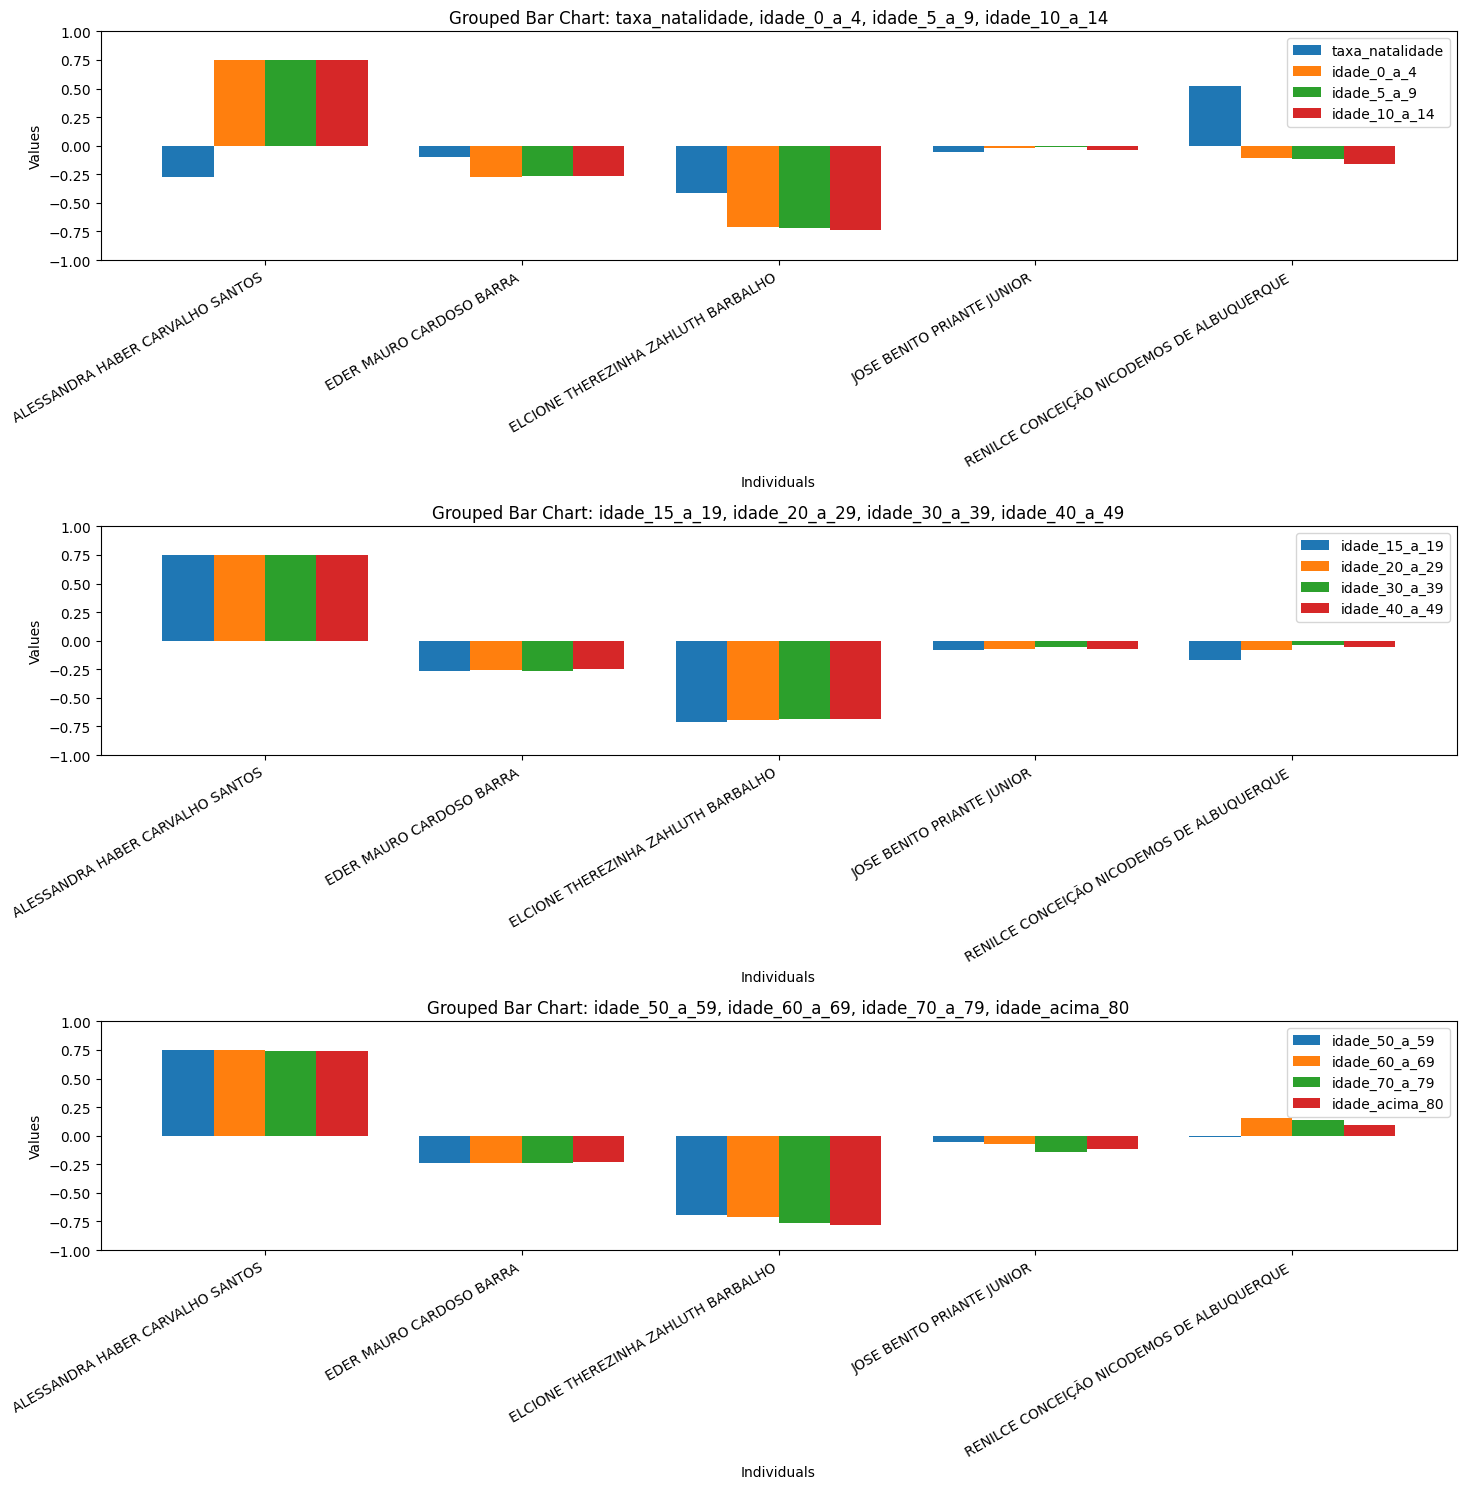

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = ['ALESSANDRA HABER CARVALHO SANTOS',
     'EDER MAURO CARDOSO BARRA',
     'ELCIONE THEREZINHA ZAHLUTH BARBALHO',
     'JOSE BENITO PRIANTE JUNIOR',
     'RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE']

y = {
    'taxa_natalidade': [-0.27223012137296204,
                        -0.10285236496529021,
                        -0.41059915039560685,
                        -0.05320221723022622,
                        0.5248698947793042],
    'idade_0_a_4': [0.7524178820158238,
                    -0.2695840479008106,
                    -0.7125917716064556,
                    -0.017871504445954284,
                    -0.10878839091009032],
    'idade_5_a_9': [0.7525307598123586,
                    -0.2672860250607761,
                    -0.722870817596484,
                    -0.007526429231673792,
                    -0.11946743608455859],
    'idade_10_a_14': [0.7514201209933433,
                      -0.26378107133842155,
                      -0.7340608068339487,
                      -0.03988071393903034,
                      -0.1584583834000603],
    'idade_15_a_19': [0.7518357918316655,
                      -0.26302637352210434,
                      -0.7135043526206382,
                      -0.07886893012824216,
                      -0.16567968073240155],
    'idade_20_a_29': [0.7531798961937748,
                      -0.26024795357834213,
                      -0.6908715629365153,
                      -0.07044801274175395,
                      -0.07957503341937743],
    'idade_30_a_39': [0.7510001279931525,
                      -0.26089177360024307,
                      -0.6870665567238261,
                      -0.05555835985552052,
                      -0.03527114726161972],
    'idade_40_a_49': [0.7501106245091507,
                      -0.25063028460707537,
                      -0.6850870954806365,
                      -0.07027842195476253,
                      -0.051499499321555335],
    'idade_50_a_59': [0.7468751216505586,
                      -0.24258672513932886,
                      -0.6928274772133132,
                      -0.057311246267209265,
                      -0.008549391746343282],
    'idade_60_a_69': [0.7487092014364974,
                      -0.23970962591316675,
                      -0.7101398159534624,
                      -0.07601512779947683,
                      0.15131269917415952],
    'idade_70_a_79': [0.743806179029998,
                      -0.2360189370819139,
                      -0.759748313906339,
                      -0.14549146909125393,
                      0.14168638041767506],
    'idade_acima_80': [0.7448338007922153,
                       -0.23131538483906944,
                       -0.7792282991383179,
                       -0.11763043375038051,
                       0.09483816406825656]
}

categories = list(y.keys())
values = np.array(list(y.values()))

# Group categories into subsets of 4
category_groups = [categories[i:i+4] for i in range(0, len(categories), 4)]
value_groups = [values[i:i+4] for i in range(0, len(values), 4)]

# Define indices for x-axis positions
indices = np.arange(len(x))

# Bar width
bar_width = 0.2

# Plot each group in separate subplots
fig, axes = plt.subplots(len(category_groups), 1, figsize=(15, 5 * len(category_groups)))
if len(category_groups) == 1:
    axes = [axes]  # Ensure axes is iterable if only one subplot

for ax, group, group_values in zip(axes, category_groups, value_groups):
    for i, category in enumerate(group):
        ax.bar(indices + i * bar_width, group_values[i], bar_width, label=category)
    
    # Adding labels and title
    ax.set_xlabel('Individuals')
    ax.set_ylabel('Values')
    ax.set_title(f'Grouped Bar Chart: {", ".join(group)}')
    ax.set_xticks(indices + bar_width * (len(group) - 1) / 2)
    ax.set_xticklabels(x, rotation=30, ha='right')
    ax.legend()
    ax.set_ylim(-1, 1)  # Set y-axis limits

# Adjust layout and show plot
plt.tight_layout()
plt.show()


# Correlação - dados fonte adicional

In [114]:
top_5_candidatos = [
    'ALESSANDRA HABER CARVALHO SANTOS',
    'EDER MAURO CARDOSO BARRA',
    'ELCIONE THEREZINHA ZAHLUTH BARBALHO',
    'JOSE BENITO PRIANTE JUNIOR',
    'RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE'
]

indices = { "cobertura_vacinal": [] }

for c in top_5_candidatos:
    dados = engine.execute(f"""
        select
        	perc_votos_municipio.*,
        	avg(dm.cobertura)
        from (
        	select
        		cast(vc.num_votos as float) / (select sum(num_votos) from voto_candidato where m.id = voto_candidato.id_municipio) as perc_votos,
        		dm.id_municipio
        	from demografia_municipio dm
        	inner join municipio m on m.id = dm.id_municipio
        	inner join voto_candidato vc on vc.id_municipio = m.id
        	inner join candidato c on c.id = vc.id_candidato
        	where c.nome = '{c}'
        	order by perc_votos desc
        	limit 10
        ) as perc_votos_municipio
        inner join vacinacao_municipio as dm on dm.id_municipio = perc_votos_municipio.id_municipio 
        group by perc_votos_municipio.id_municipio, perc_votos_municipio.perc_votos
        order by perc_votos_municipio.perc_votos desc
    """).fetchall()
    print(c)
    indices["cobertura_vacinal"].append(scipy.stats.pearsonr(x, [i[1] for i in dados]).statistic)
    print("=======================")

ALESSANDRA HABER CARVALHO SANTOS
EDER MAURO CARDOSO BARRA
ELCIONE THEREZINHA ZAHLUTH BARBALHO
JOSE BENITO PRIANTE JUNIOR
RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE


In [115]:
indices

{'cobertura_vacinal': [-0.3540811799577246,
  0.18179751272288974,
  0.25700503437643396,
  -0.6539119963199844,
  -0.1632904370357358]}

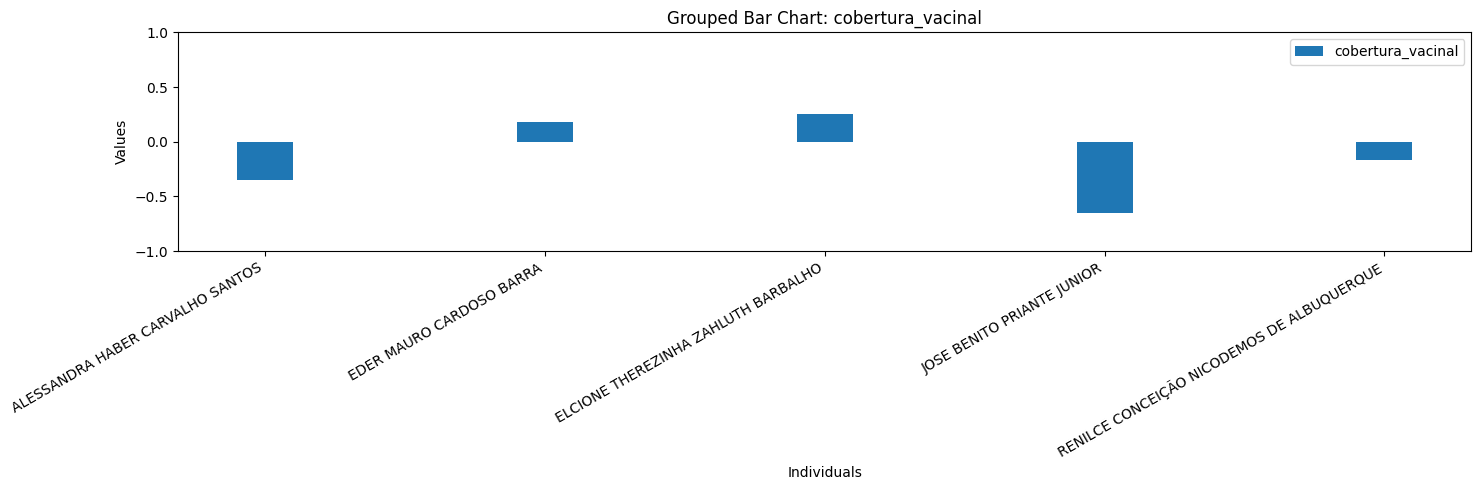

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = ['ALESSANDRA HABER CARVALHO SANTOS',
     'EDER MAURO CARDOSO BARRA',
     'ELCIONE THEREZINHA ZAHLUTH BARBALHO',
     'JOSE BENITO PRIANTE JUNIOR',
     'RENILCE CONCEIÇÃO NICODEMOS DE ALBUQUERQUE']

y = {'cobertura_vacinal': [-0.3540811799577246,
  0.18179751272288974,
  0.25700503437643396,
  -0.6539119963199844,
  -0.1632904370357358]}

categories = list(y.keys())
values = np.array(list(y.values()))

# Group categories into subsets of 4
category_groups = [categories[i:i+4] for i in range(0, len(categories), 4)]
value_groups = [values[i:i+4] for i in range(0, len(values), 4)]

# Define indices for x-axis positions
indices = np.arange(len(x))

# Bar width
bar_width = 0.2

# Plot each group in separate subplots
fig, axes = plt.subplots(len(category_groups), 1, figsize=(15, 5 * len(category_groups)))
if len(category_groups) == 1:
    axes = [axes]  # Ensure axes is iterable if only one subplot

for ax, group, group_values in zip(axes, category_groups, value_groups):
    for i, category in enumerate(group):
        ax.bar(indices + i * bar_width, group_values[i], bar_width, label=category)
    
    # Adding labels and title
    ax.set_xlabel('Individuals')
    ax.set_ylabel('Values')
    ax.set_title(f'Grouped Bar Chart: {", ".join(group)}')
    ax.set_xticks(indices + bar_width * (len(group) - 1) / 2)
    ax.set_xticklabels(x, rotation=30, ha='right')
    ax.legend()
    ax.set_ylim(-1, 1)  # Set y-axis limits

# Adjust layout and show plot
plt.tight_layout()
plt.show()


# Autocorrelação espacial por partido

In [129]:
dados = engine.execute("""
SELECT sum(vc.num_votos), substr(cast(c.numero as varchar), 1,2) as partido, m.nome as nome_municipio, ST_AsText(m.geom)
FROM voto_candidato as vc
INNER JOIN municipio as m
  ON m.id = vc.id_municipio
INNER JOIN candidato as c
  ON c.id = vc.id_candidato
WHERE c.numero >= 1000 or c.numero <= 90
GROUP BY substr(cast(c.numero as varchar), 1,2), ST_AsText(m.geom), m.nome
""").fetchall()

In [130]:
df = pd.DataFrame(
    {
        "num_votos": [i[0] for i in dados],
        "partido": [i[1] for i in dados],
        "municipio_id":[i[2] for i in dados],
        "geometry": [i[3] for i in dados],
        
    }
)

In [131]:
from shapely import wkt
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
gdf = GeoDataFrame(df, crs="EPSG:4674")

In [134]:
def plot_all_municipio(partido, p=[0.01, 0.05, 0.1]):
    gdf_k = gdf[gdf['partido'] == partido]
    
    df = gdf_k
    wq =  lps.weights.Queen.from_dataframe(df)
    wq.transform = 'r'
    
    y = df['num_votos']
    ylag = lps.weights.lag_spatial(wq, y)
    
    ylagq5 = mc.Quantiles(ylag, k=5)
    
    f, ax = plt.subplots(1, figsize=(9, 9))
    df.assign(cl=ylagq5.yb).plot(column='cl', categorical=True, \
            k=5, cmap='GnBu', linewidth=0.1, ax=ax, \
            edgecolor='white', legend=True)
    ax.set_axis_off()
    plt.title("Spatial Lag - Número de Votos (Quantiles)")
    plt.savefig(f"./images/partido-individual-numero-votos-{partido}-spatial-lag.png", bbox_inches='tight')
    plt.show()

    wq.transform = 'r'
    lag_price = lps.weights.lag_spatial(wq, df['num_votos'])
    price = df['num_votos']
    b, a = np.polyfit(price, lag_price, 1)
    f, ax = plt.subplots(1, figsize=(9, 9))
    plt.plot(price, lag_price, '.', color='firebrick')
    plt.vlines(price.mean(), lag_price.min(), lag_price.max(), linestyle='--')
    plt.hlines(lag_price.mean(), price.min(), price.max(), linestyle='--')
    plt.plot(price, a + b*price, 'r')
    plt.title('Moran Scatterplot')
    plt.ylabel('Spatial Lag - Número de Votos')
    plt.xlabel('Número de Votos')
    plt.savefig(f"./images/partido-individual-numero-votos-{partido}-moran-scatterplot.png", bbox_inches='tight')
    plt.show()

    for _p in p:
        li = esda.moran.Moran_Local(y, wq)    
        sig = 1 * (li.p_sim < _p)
        hotspot = 1 * (sig * li.q==1)
        coldspot = 3 * (sig * li.q==3)
        doughnut = 2 * (sig * li.q==2)
        diamond = 4 * (sig * li.q==4)
        spots = hotspot + coldspot + doughnut + diamond
        spots
        
        spot_labels = [ '0 Not Significant', '1 High-High', '2 Low-High', '3 Low-Low', '4 High-Low']
        colors_names = [ 'lightgrey', 'red', 'lightblue', 'blue', 'pink']

        spots_unique = set(spots)
        colors_names = [colors_names[i] for i in spots_unique]

        labels = [spot_labels[i] for i in spots]
        
        hmap = colors.ListedColormap(colors_names)
        f, ax = plt.subplots(1, figsize=(9, 9))
        df.assign(cl=labels).plot(column='cl',categorical=True, \
                k=2, cmap=hmap, linewidth=0.1, ax=ax, \
                edgecolor='white', legend=True)
        ax.set_axis_off()
        plt.savefig(f"./images/partido-individual-numero-votos-{partido}-{_p}-moran.png", bbox_inches='tight')
        plt.show()

/tmp/ipykernel_8642/2508678846.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


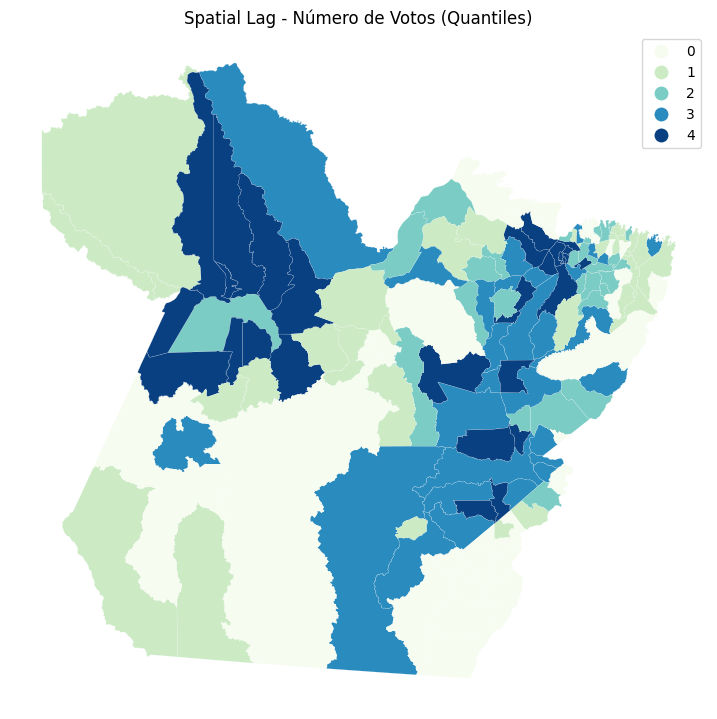

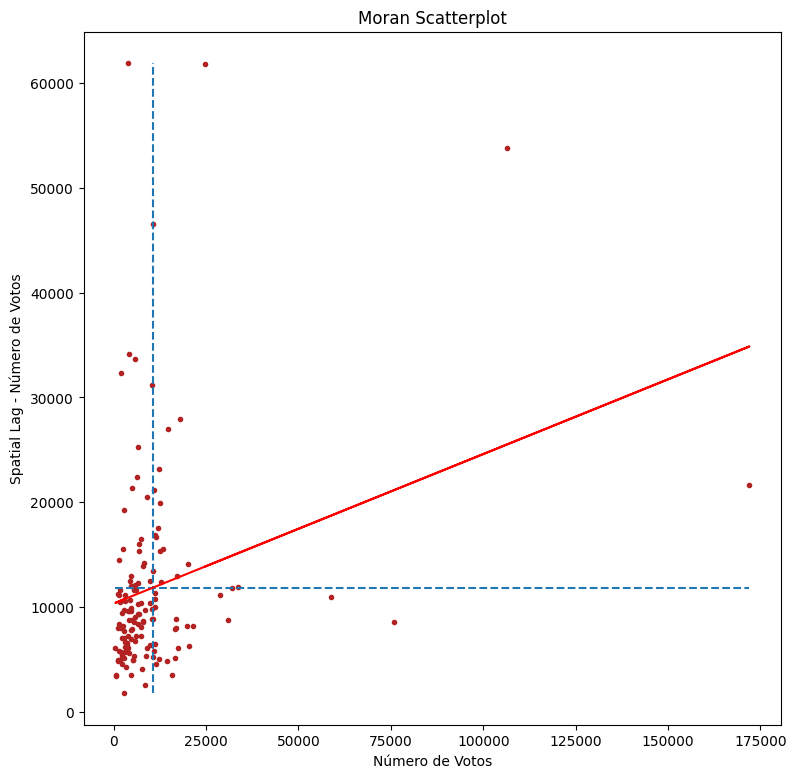

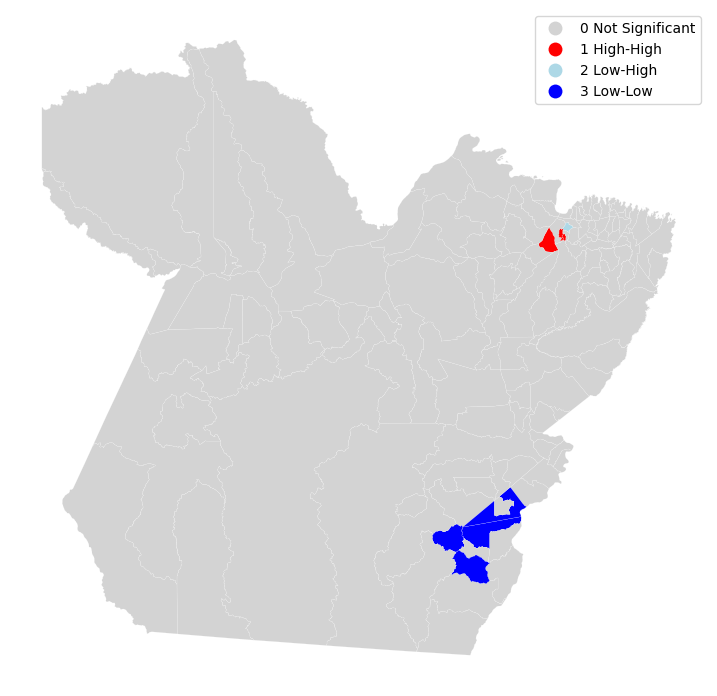

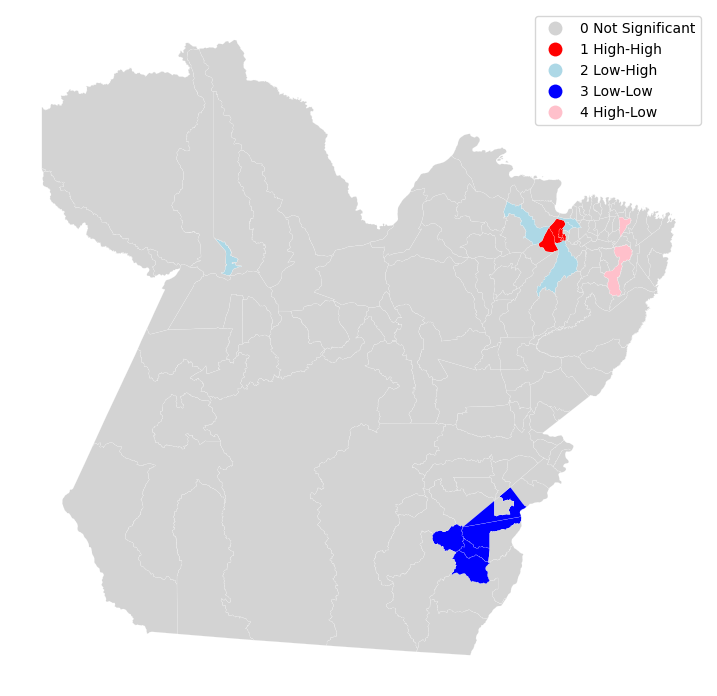

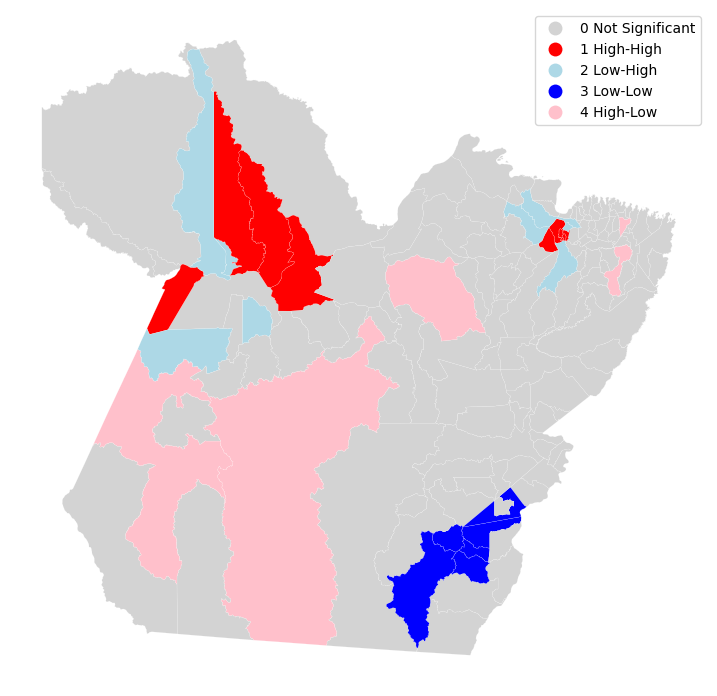

/tmp/ipykernel_8642/2508678846.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


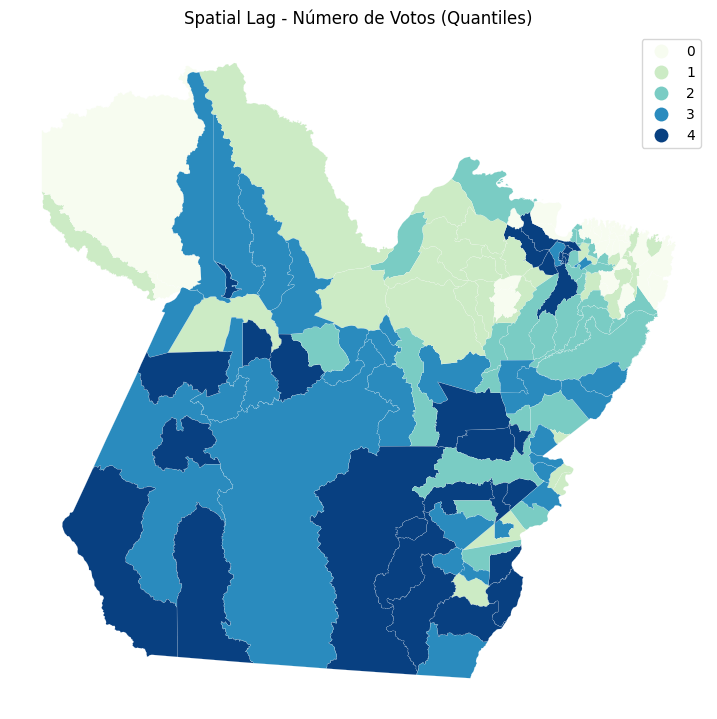

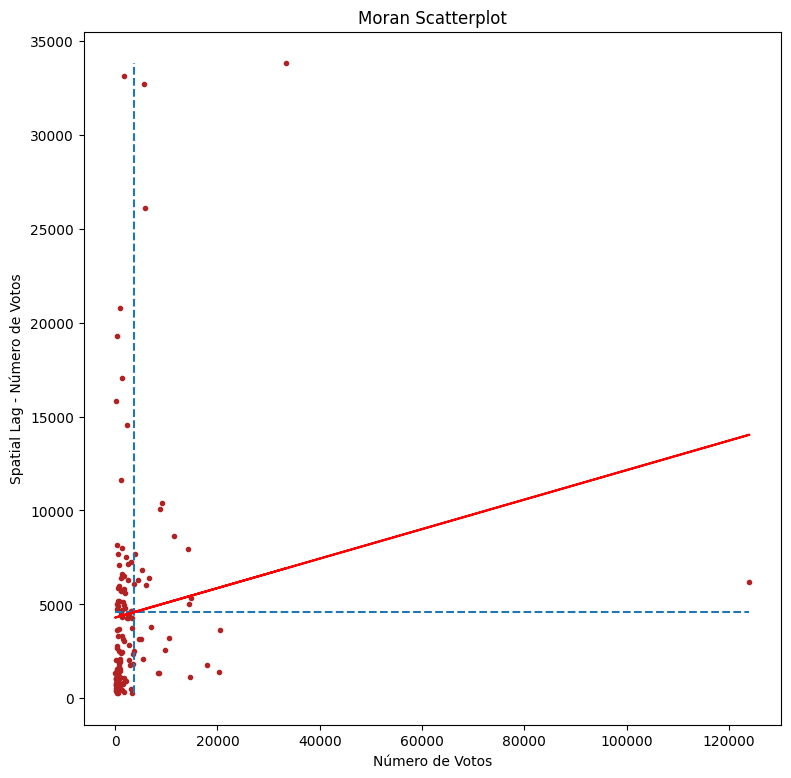

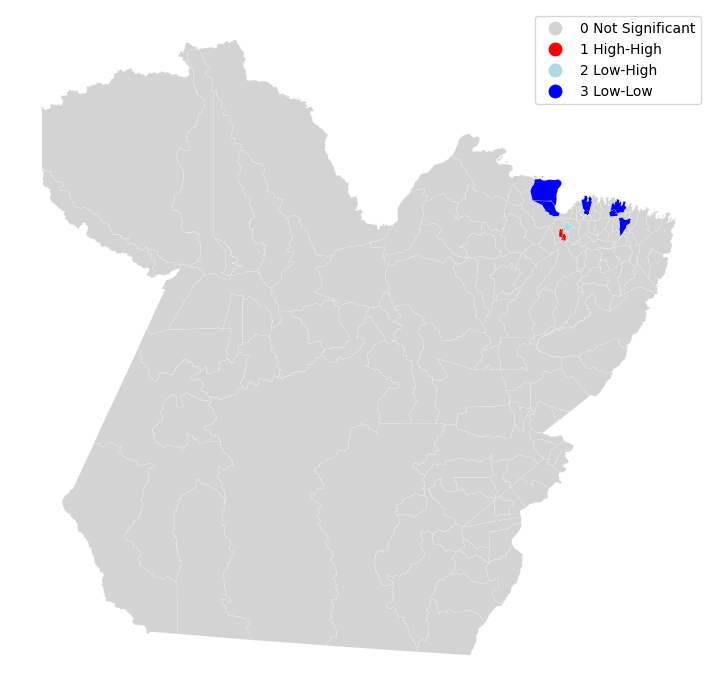

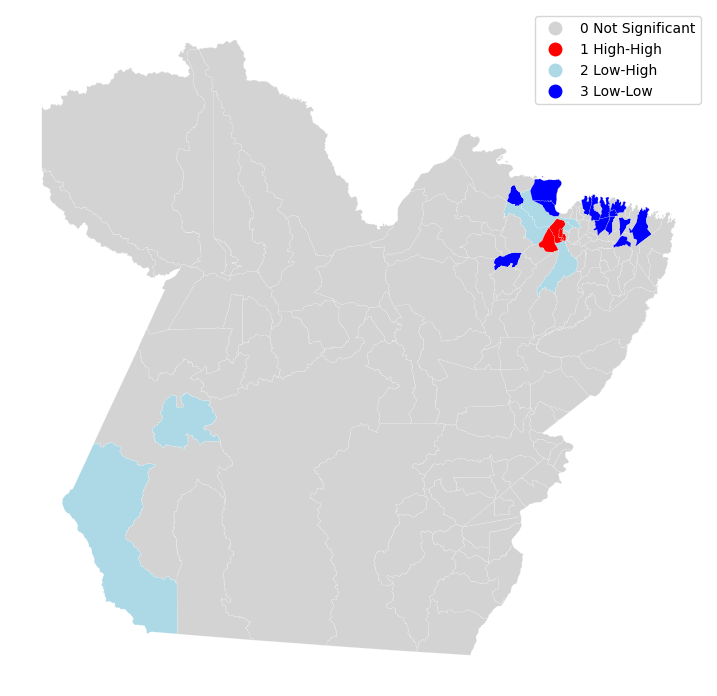

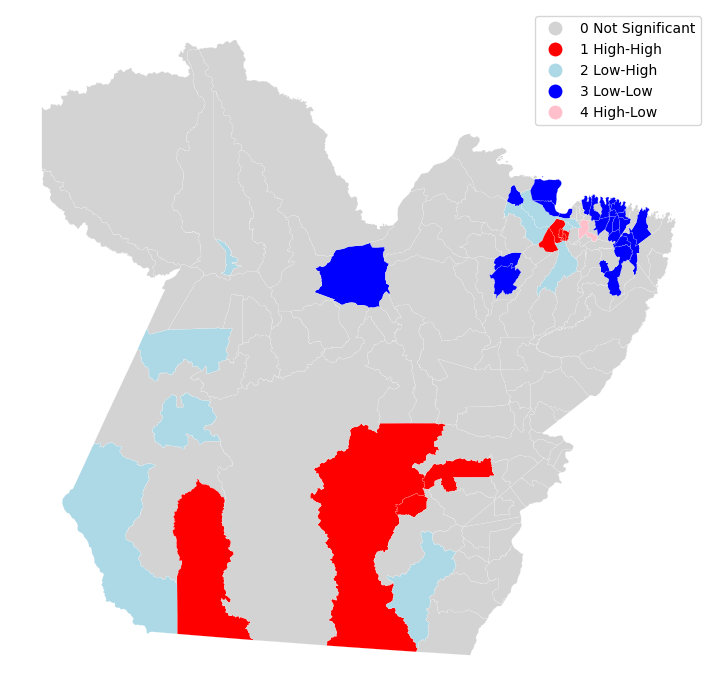

/tmp/ipykernel_8642/2508678846.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


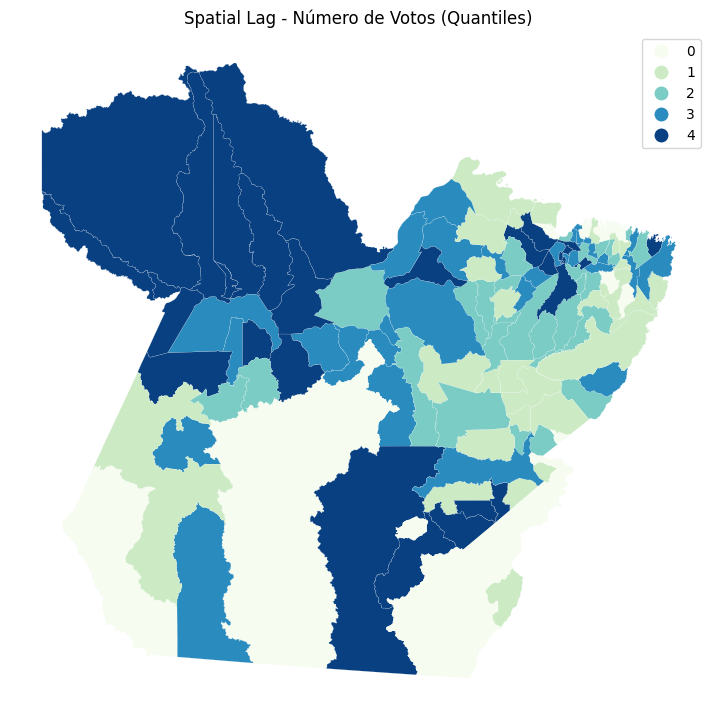

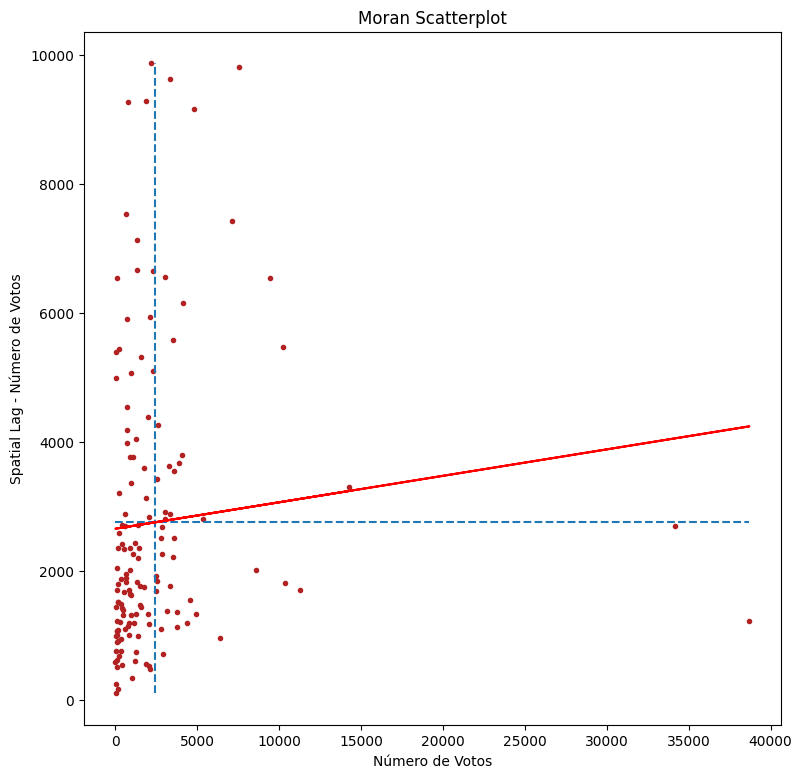

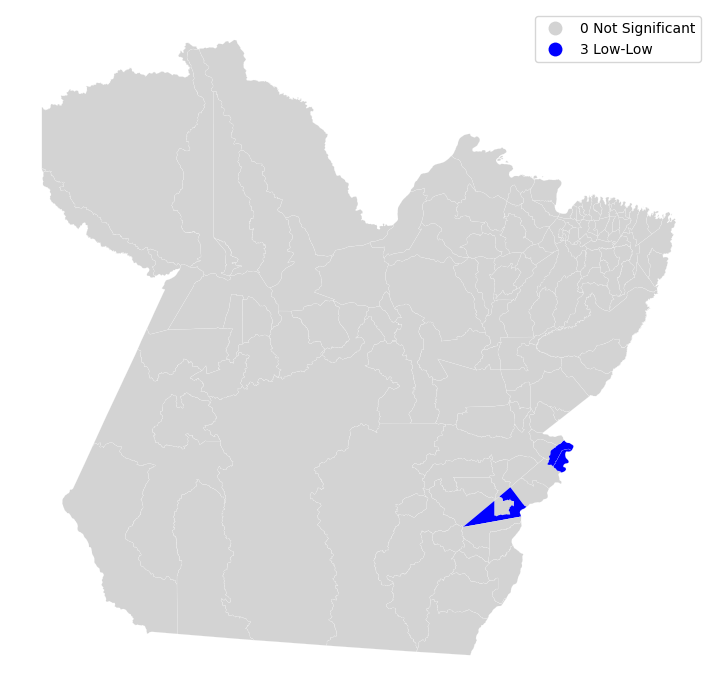

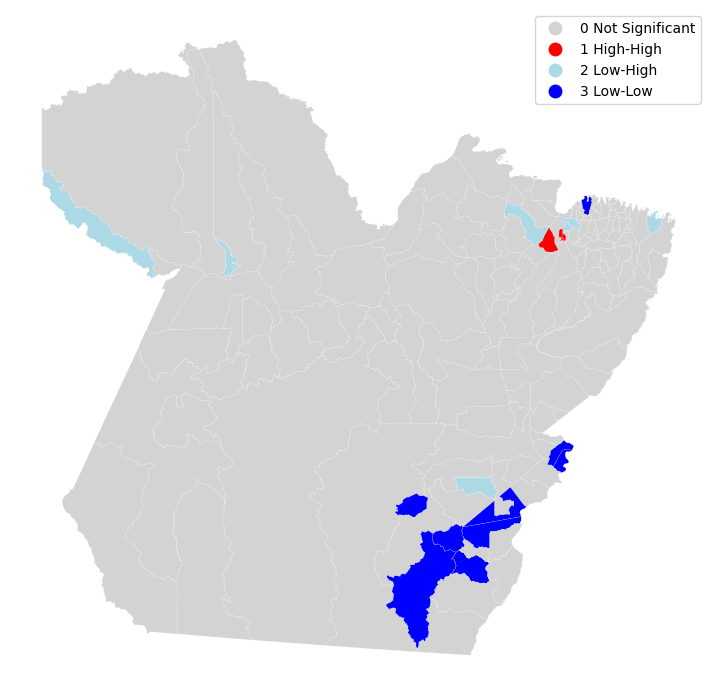

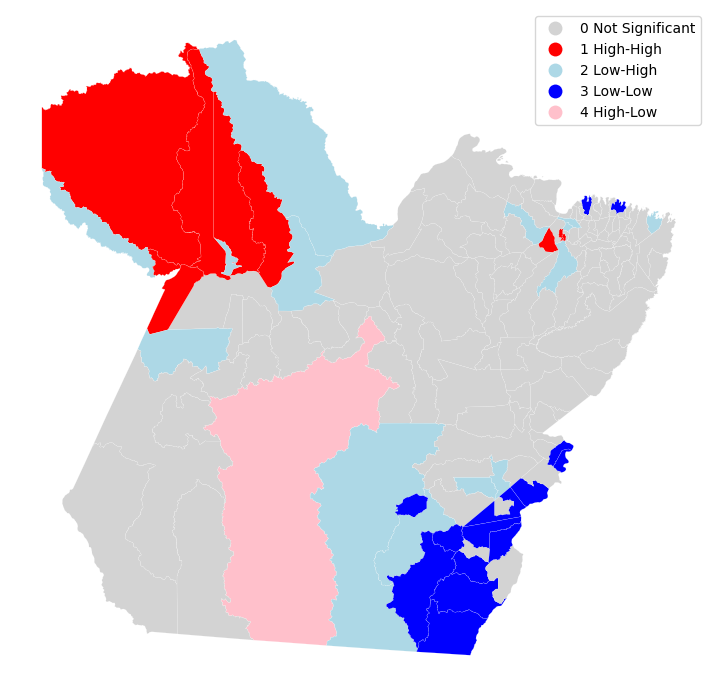

/tmp/ipykernel_8642/2508678846.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


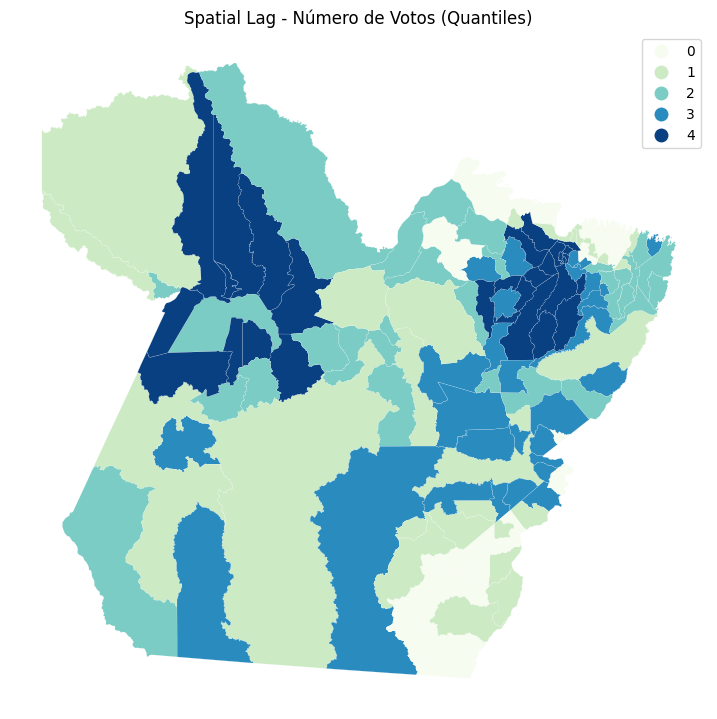

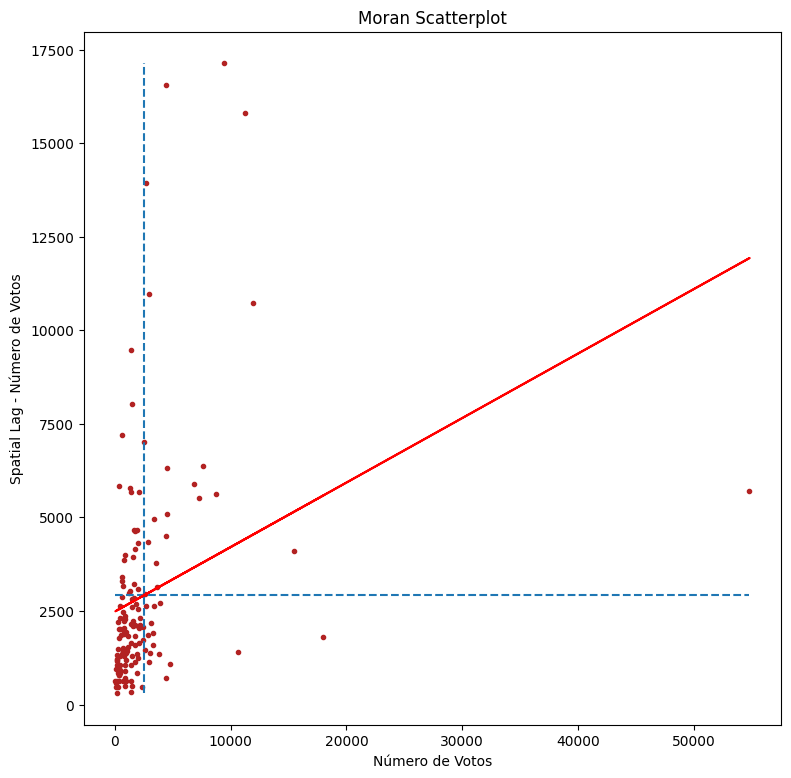

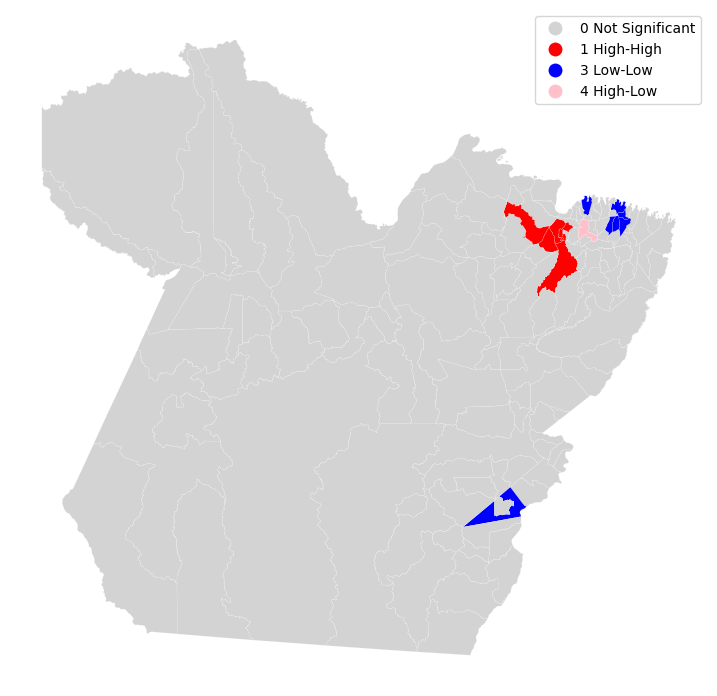

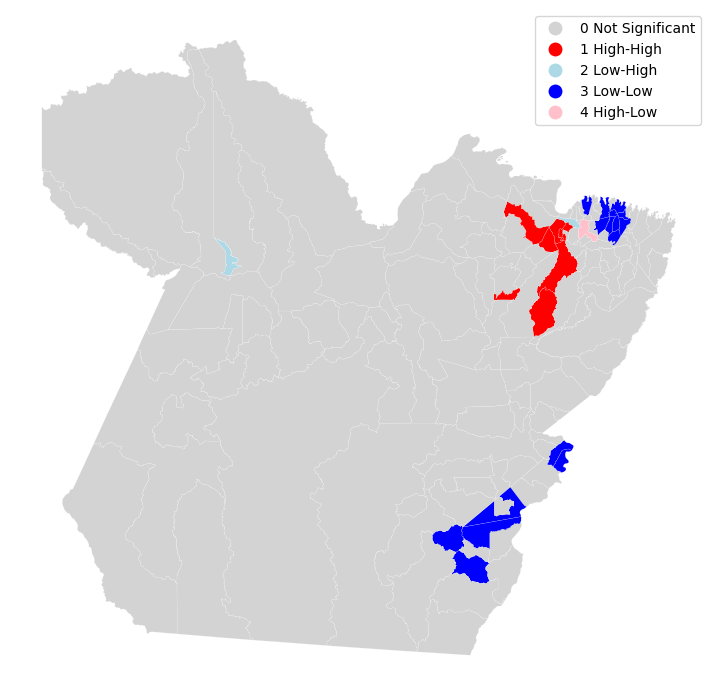

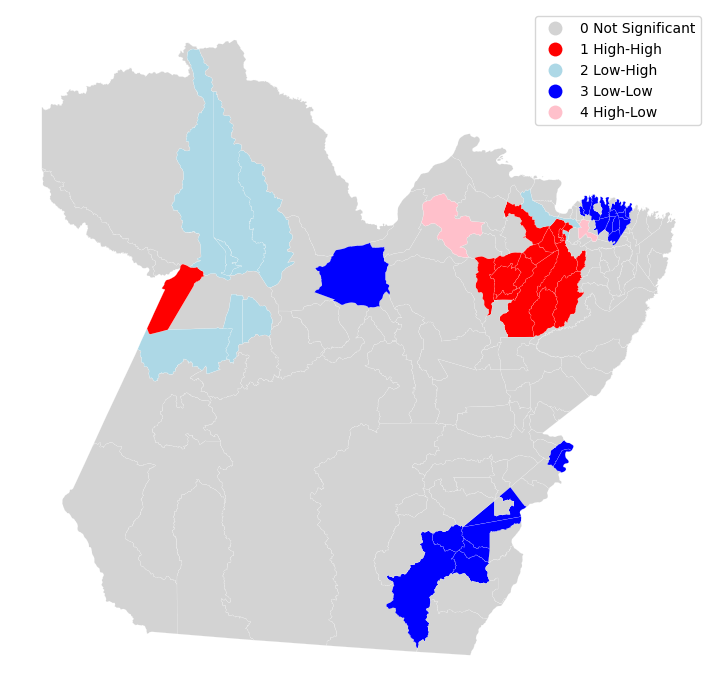

/tmp/ipykernel_8642/2508678846.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


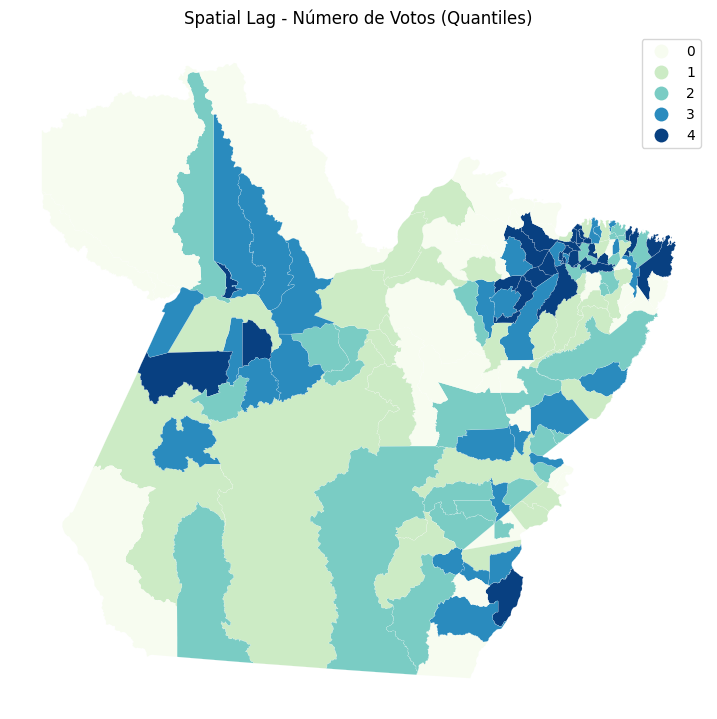

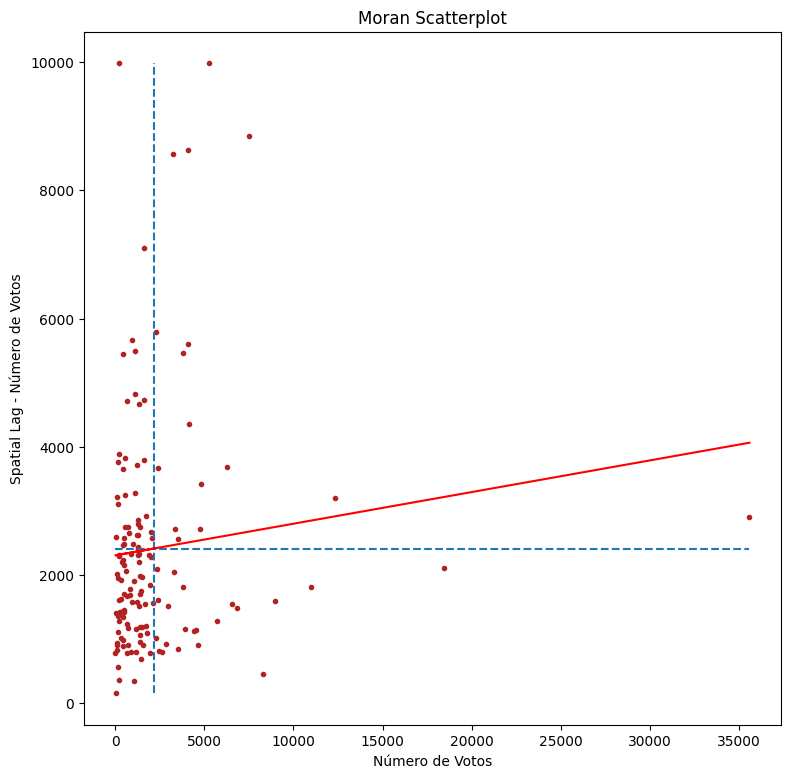

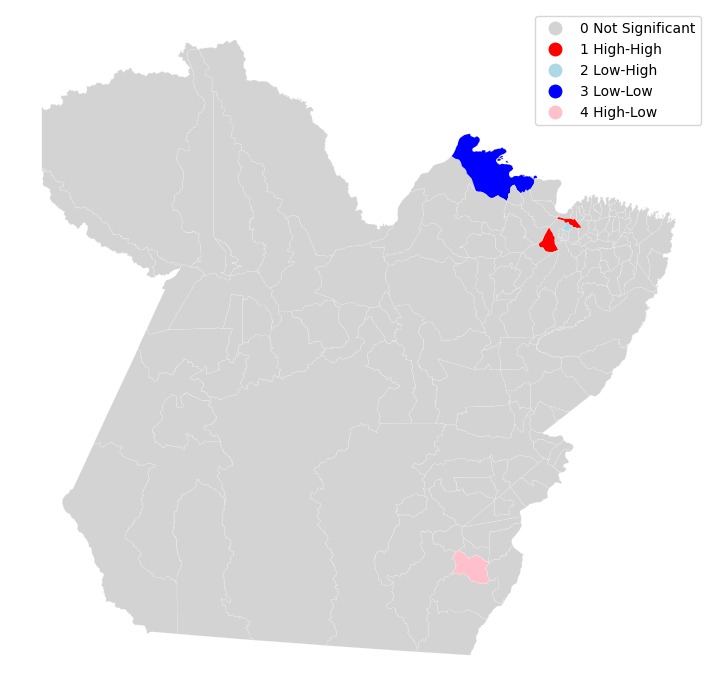

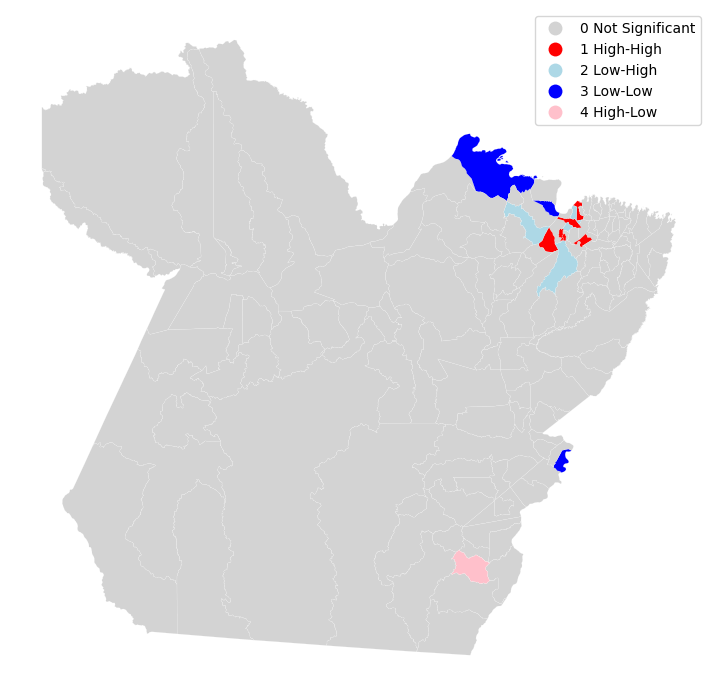

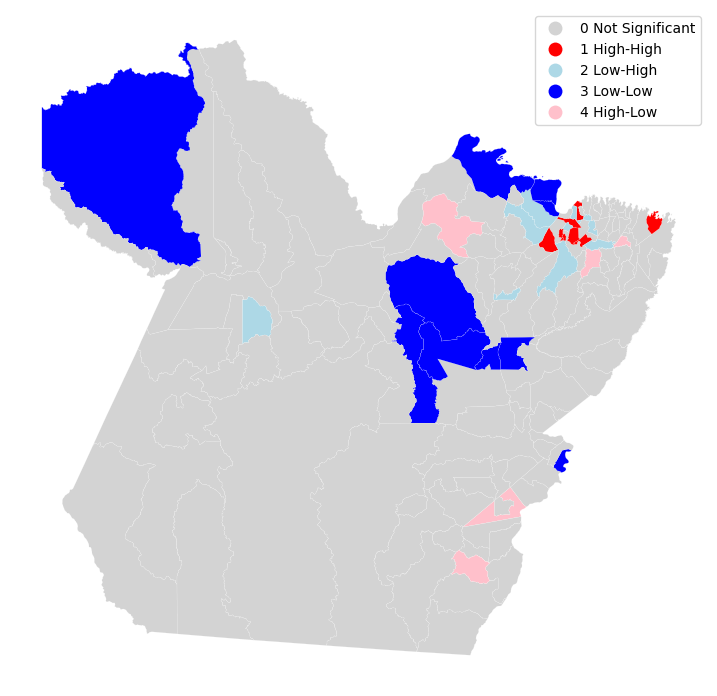

In [135]:
plot_all_municipio('15')
plot_all_municipio('22')
plot_all_municipio('55')
plot_all_municipio('13')
plot_all_municipio('44')

# Análise extra
Agrupando partidos entre esquerda, direita e centro

In [121]:
esquerda = ['13', '50', '40', '65', '77', '96', '28', '14', '43']
# 13: Partido dos Trabalhadores (PT)
# 50: Partido Socialismo e Liberdade (PSOL)
# 40: Partido Socialista Brasileiro (PSB)
# 65: Partido Comunista do Brasil (PCdoB)
# 77: Solidariedade (SD)
# 96: Unidade Popular (UP)
# 28: Partido Comunista Brasileiro (PCB)
# 14: Partido Trabalhista Brasileiro (PTB)
# 43: Partido Verde (PV)

direita = ['22', '10', '14', '35', '55', '18', '36', '12', '44']
# 22: Partido Liberal (PL)
# 10: Republicanos
# 14: Partido Trabalhista Brasileiro (PTB)
# 35: Partido da Mulher Brasileira (PMB)
# 55: Progressistas (PP)
# 18: Patriota (PATRI)
# 12: Partido Social Cristão (PSC)
# 44: União Brasil

centro = ['36', '15', '23', '19', '20', '70']
# 36: Partido da Mobilização Nacional (PMN)
# 15: Movimento Democrático Brasileiro (MDB)
# 23: Cidadania
# 19: Podemos
# 20: Agir (antigo PTC)
# 70: Avante

In [125]:
def plot_all_municipio(partidos, p=[0.01, 0.05, 0.1]):
    gdf_k = gdf[gdf['partido'].isin(partidos)]
    
    df = gdf_k
    wq =  lps.weights.Queen.from_dataframe(df)
    wq.transform = 'r'
    
    y = df['num_votos']
    ylag = lps.weights.lag_spatial(wq, y)
    
    ylagq5 = mc.Quantiles(ylag, k=5)
    
    f, ax = plt.subplots(1, figsize=(9, 9))
    df.assign(cl=ylagq5.yb).plot(column='cl', categorical=True, \
            k=5, cmap='GnBu', linewidth=0.1, ax=ax, \
            edgecolor='white', legend=True)
    ax.set_axis_off()
    plt.title("Spatial Lag - Número de Votos (Quantiles)")
    plt.savefig(f"./images/partido-numero-votos-{'-'.join(partidos)}-spatial-lag.png", bbox_inches='tight')
    plt.show()

    wq.transform = 'r'
    lag_price = lps.weights.lag_spatial(wq, df['num_votos'])
    price = df['num_votos']
    b, a = np.polyfit(price, lag_price, 1)
    f, ax = plt.subplots(1, figsize=(9, 9))
    plt.plot(price, lag_price, '.', color='firebrick')
    plt.vlines(price.mean(), lag_price.min(), lag_price.max(), linestyle='--')
    plt.hlines(lag_price.mean(), price.min(), price.max(), linestyle='--')
    plt.plot(price, a + b*price, 'r')
    plt.title('Moran Scatterplot')
    plt.ylabel('Spatial Lag - Número de Votos')
    plt.xlabel('Número de Votos')
    plt.savefig(f"./images/partido-numero-votos-{'-'.join(partidos)}-moran-scatterplot.png", bbox_inches='tight')
    plt.show()

    for _p in p:
        li = esda.moran.Moran_Local(y, wq)    
        sig = 1 * (li.p_sim < _p)
        hotspot = 1 * (sig * li.q==1)
        coldspot = 3 * (sig * li.q==3)
        doughnut = 2 * (sig * li.q==2)
        diamond = 4 * (sig * li.q==4)
        spots = hotspot + coldspot + doughnut + diamond
        spots
        
        spot_labels = [ '0 Not Significant', '1 High-High', '2 Low-High', '3 Low-Low', '4 High-Low']
        colors_names = [ 'lightgrey', 'red', 'lightblue', 'blue', 'pink']

        spots_unique = set(spots)
        colors_names = [colors_names[i] for i in spots_unique]

        labels = [spot_labels[i] for i in spots]
        
        hmap = colors.ListedColormap(colors_names)
        f, ax = plt.subplots(1, figsize=(9, 9))
        df.assign(cl=labels).plot(column='cl',categorical=True, \
                k=2, cmap=hmap, linewidth=0.1, ax=ax, \
                edgecolor='white', legend=True)
        ax.set_axis_off()
        plt.savefig(f"./images/partido-numero-votos-{'-'.join(partidos)}-{_p}-moran.png", bbox_inches='tight')
        plt.show()

/tmp/ipykernel_8642/815770317.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


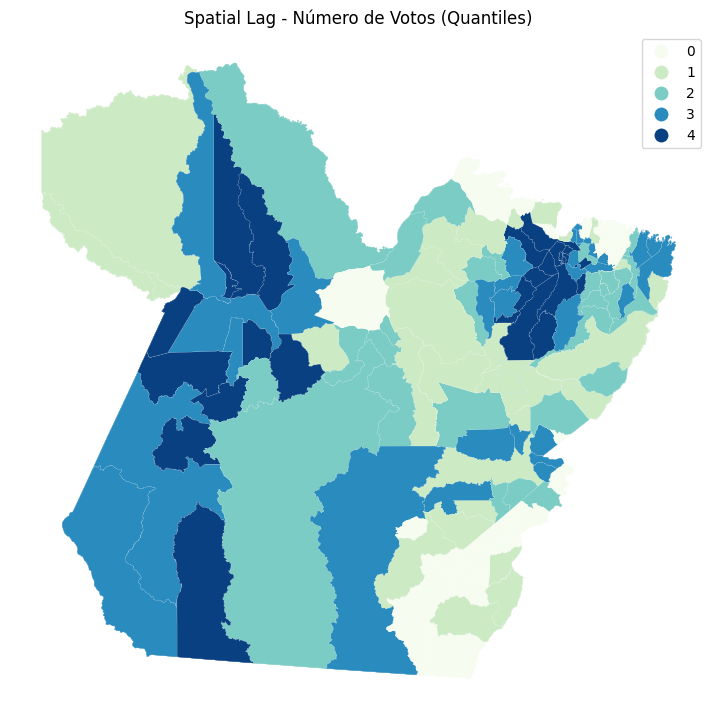

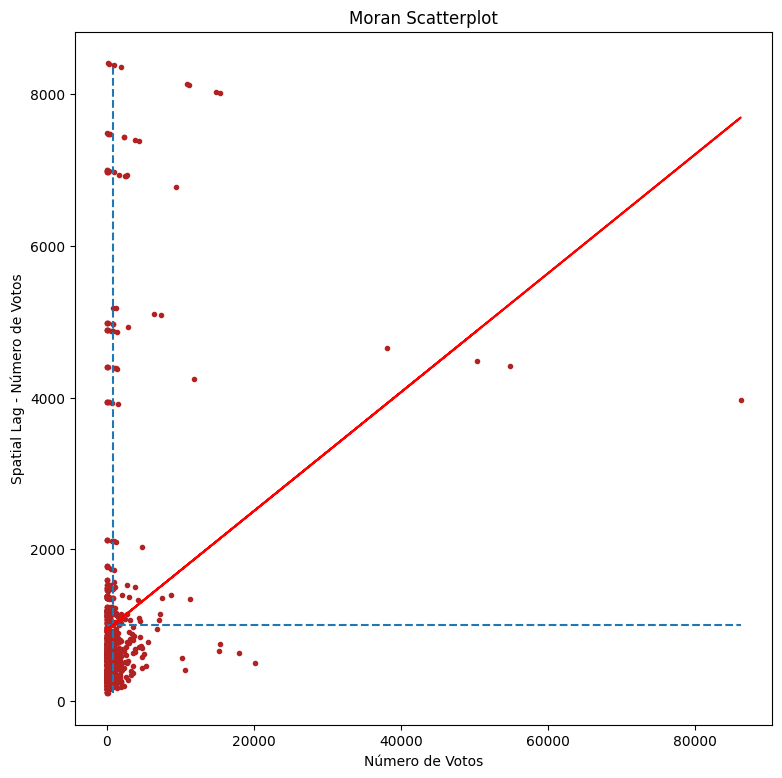

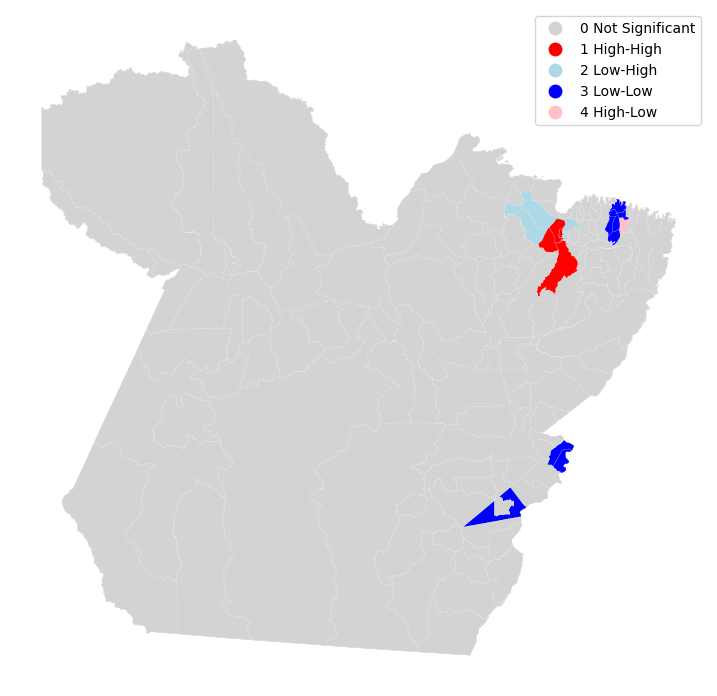

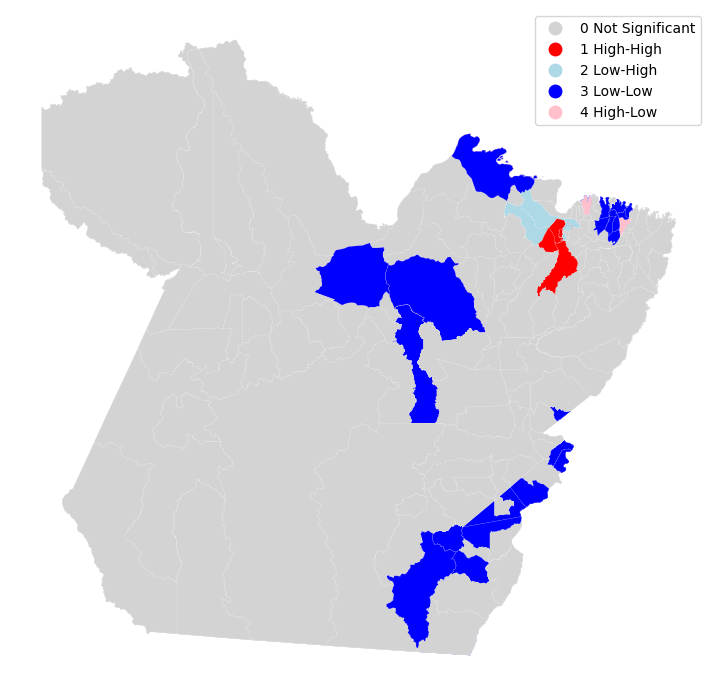

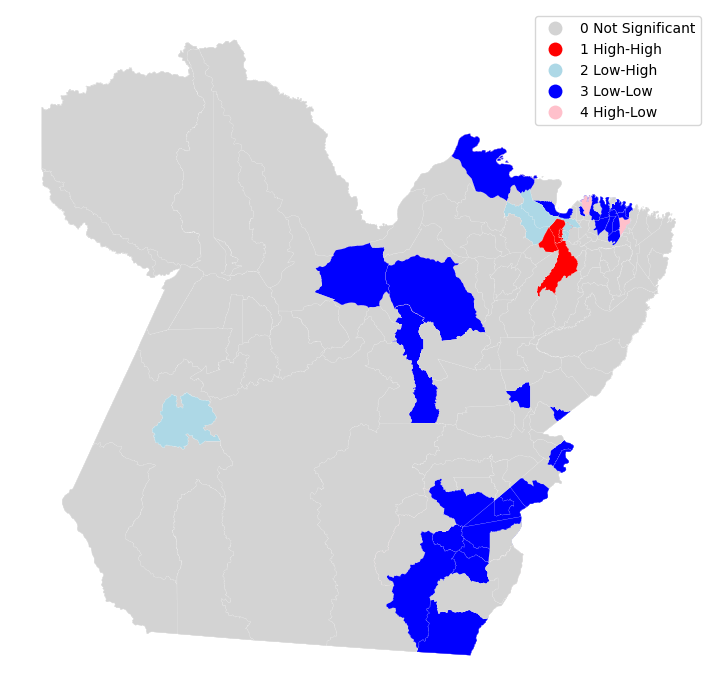

In [126]:
plot_all_municipio(esquerda)

/tmp/ipykernel_8642/815770317.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


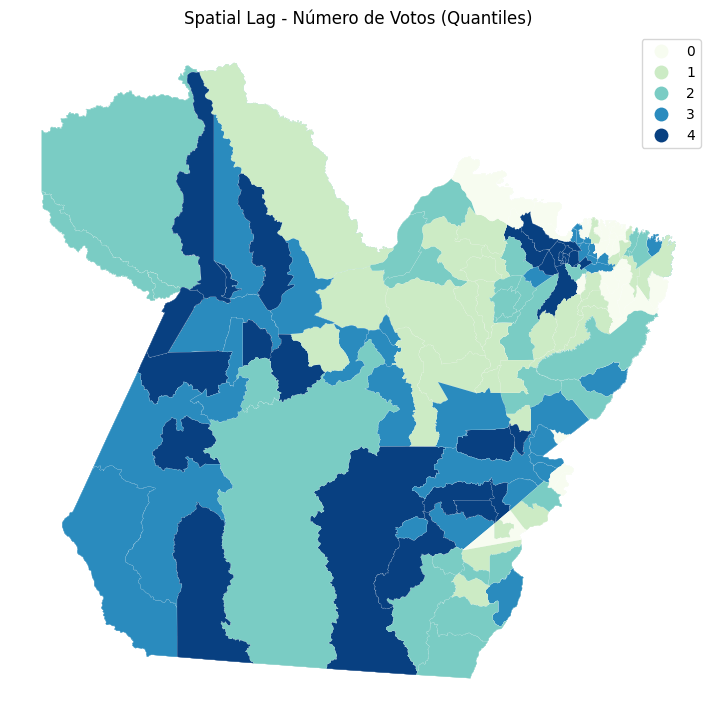

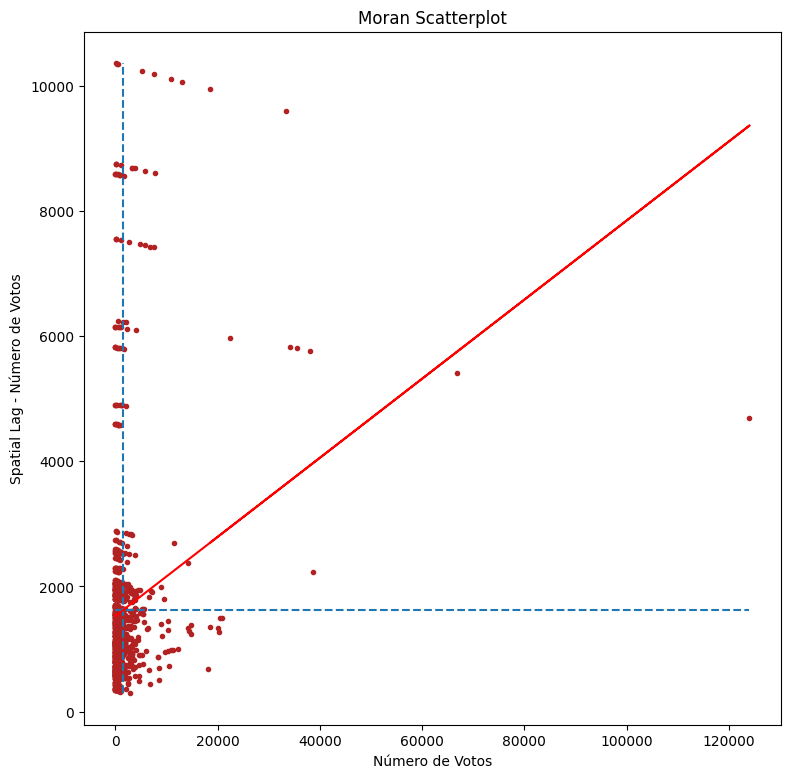

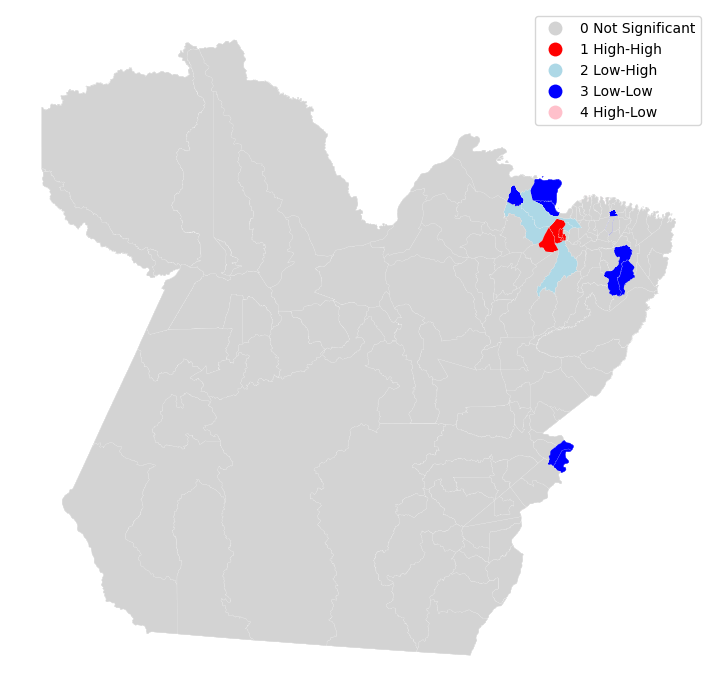

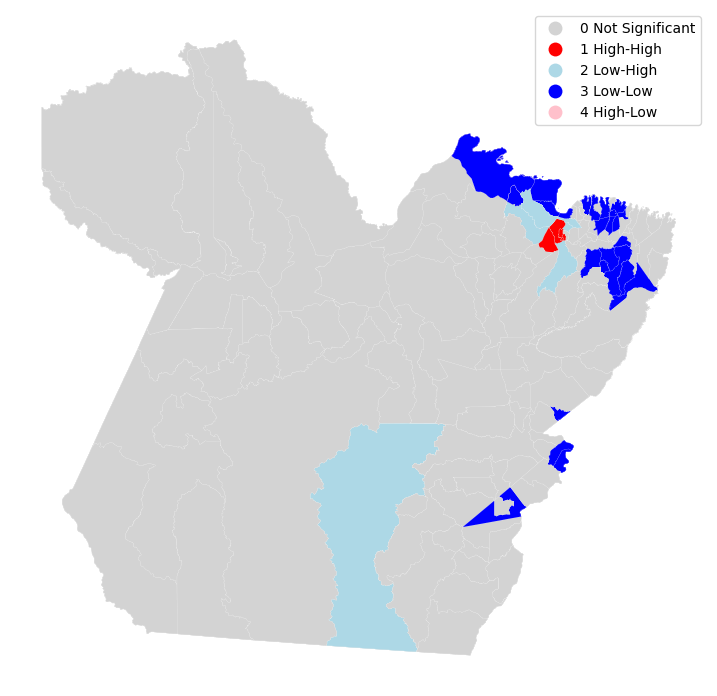

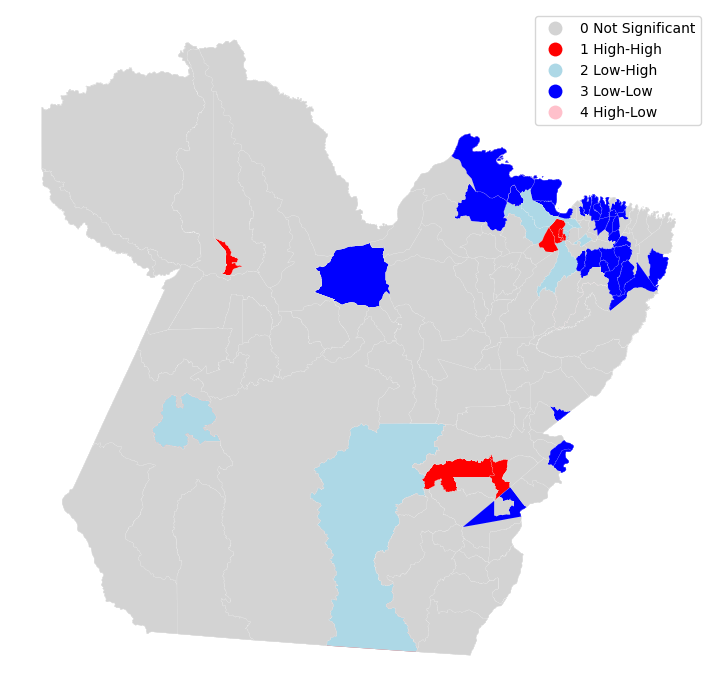

In [127]:
plot_all_municipio(direita)

/tmp/ipykernel_8642/815770317.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq =  lps.weights.Queen.from_dataframe(df)


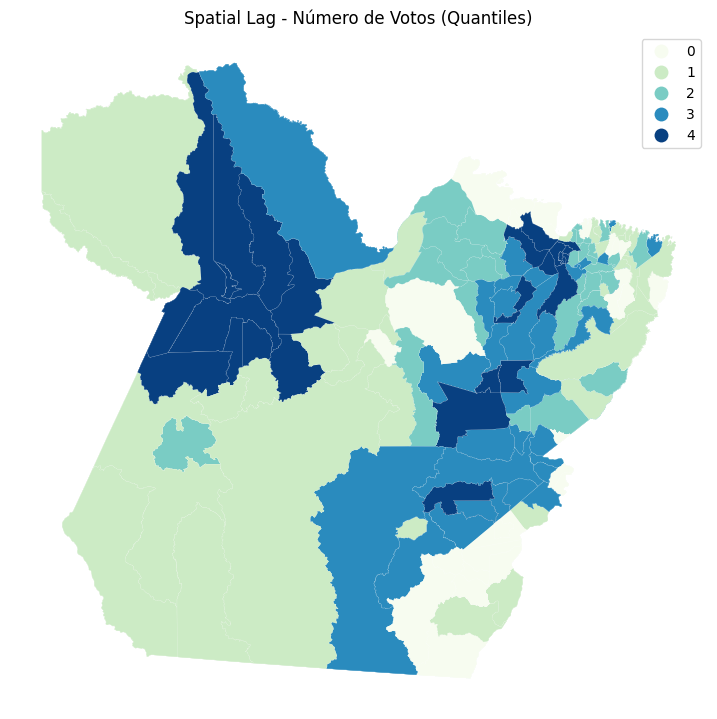

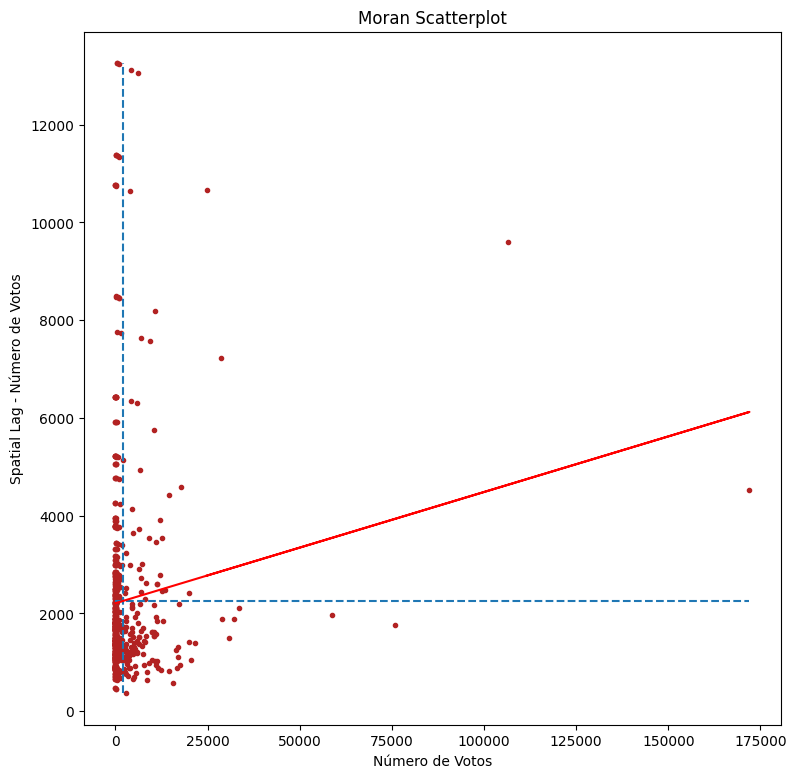

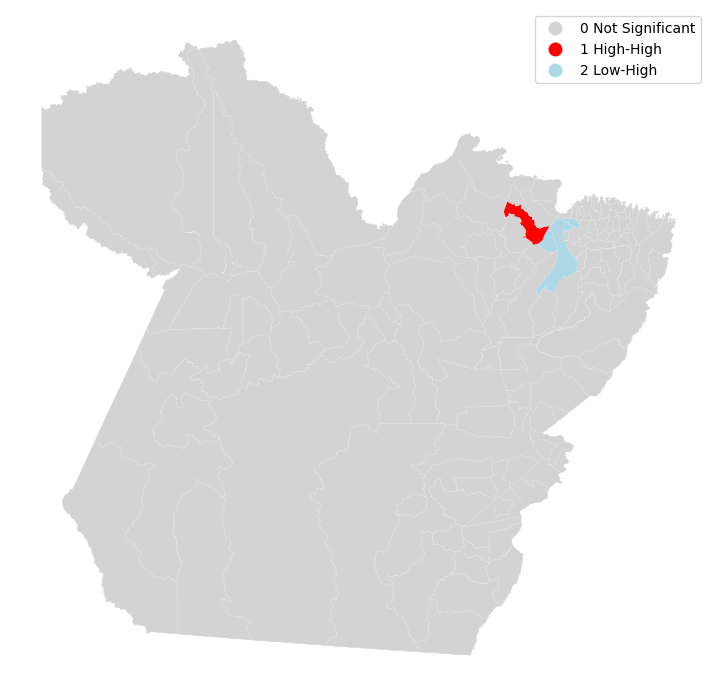

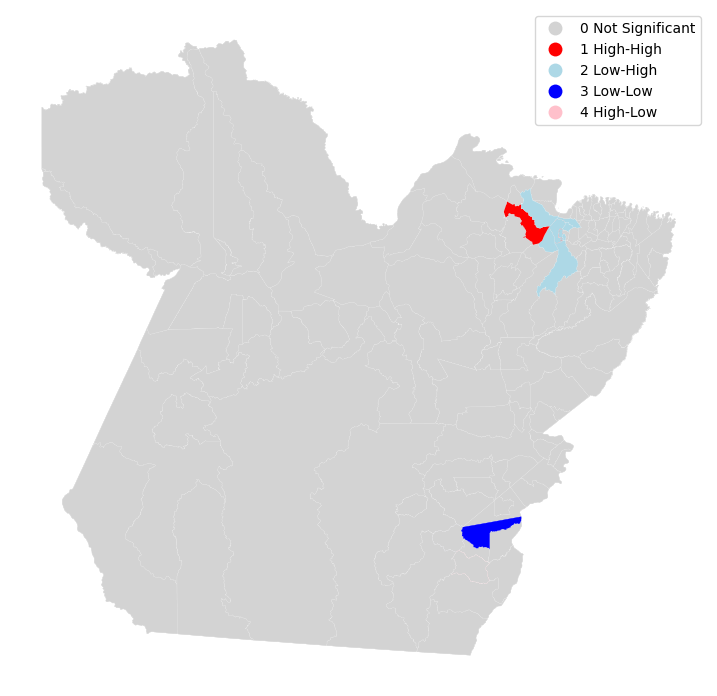

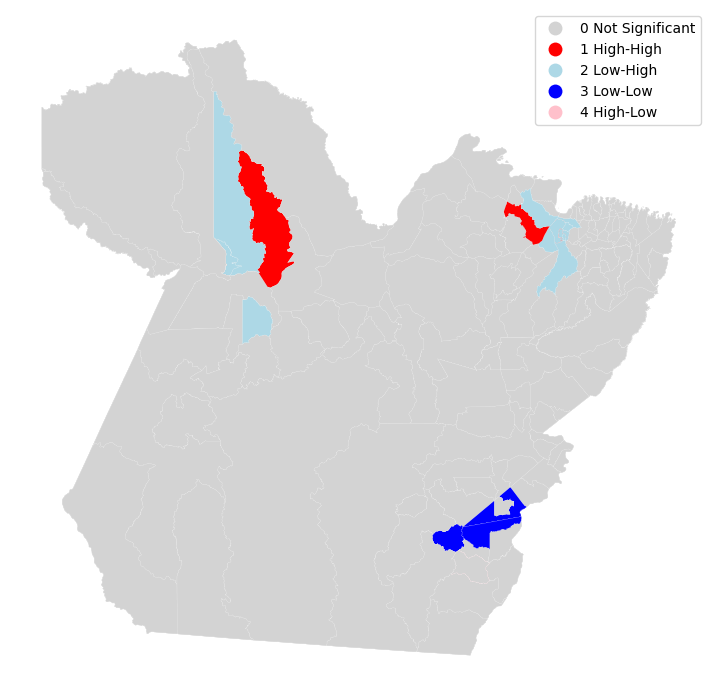

In [128]:
plot_all_municipio(centro)